### Выпраўлены праект

Крок 1: Правільнае разбіццё дадзеныx

In [1]:
# ============================================================================
# ПРАВІЛЬНАЕ РАЗБІЦЦЁ ДАНЫХ 
# ============================================================================

from sklearn.model_selection import train_test_split
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 1. Загружаем даныя
darwin = fetch_ucirepo(id=732)
X_raw = darwin.data.features
y_raw = darwin.data.targets

# 2. ВЫДАЛЯЕМ ID
X_raw = X_raw.drop(columns=['ID'])

# 3. КАДЫРУЕМ МЭТУ (P=1, H=0)
y = y_raw['class'].map({'P': 1, 'H': 0})

# 4. РАЗБІВАЕМ (з стратыфікацыяй!)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Train: {len(X_train_raw)} (P: {sum(y_train)}, H: {len(y_train)-sum(y_train)})")
print(f"✅ Test: {len(X_test_raw)} (P: {sum(y_test)}, H: {len(y_test)-sum(y_test)})")

✅ Train: 139 (P: 71, H: 68)
✅ Test: 35 (P: 18, H: 17)


Крок 2: EDA і агрэгацыя ТОЛЬКІ НА TRAIN


In [2]:
# ============================================================================
# EDA І АГРЭГАЦЫЯ ТОЛЬКІ НА TRAIN
# ============================================================================

# 1. Групоўка прыкмет (удасканалены рэгулярны выраз)
import re

def extract_prefix(col_name):
    return re.sub(r'_?\d+$', '', col_name)

feature_groups = {}
for col in X_train_raw.columns:
    prefix = extract_prefix(col)
    if prefix not in feature_groups:
        feature_groups[prefix] = []
    feature_groups[prefix].append(col)

# 2. Агрэгацыя па катэгорыях (толькі на train!)
task_categories = {
    1: 'M', 2: 'G', 3: 'G', 4: 'G', 5: 'G', 
    6: 'C', 7: 'C', 8: 'C', 9: 'C', 10: 'C',
    11: 'C', 12: 'C', 13: 'C', 14: 'M', 15: 'C', 
    16: 'C', 17: 'C', 18: 'M', 19: 'C', 20: 'M', 
    21: 'G', 22: 'C', 23: 'M', 24: 'G', 25: 'C'
}

category_tasks = {
    'G': [k for k, v in task_categories.items() if v == 'G'],
    'C': [k for k, v in task_categories.items() if v == 'C'],
    'M': [k for k, v in task_categories.items() if v == 'M']
}

# Ствараем агрэгаваныя прыкметы ТОЛЬКІ НА TRAIN
X_train_agg = pd.DataFrame(index=X_train_raw.index)
for group, cols in feature_groups.items():
    if group == 'ID':
        continue
    for category, task_list in category_tasks.items():
        cat_cols = [c for c in cols if int(c[-1]) in task_list]
        if len(cat_cols) > 0:
            X_train_agg[f'{group}_{category}_mean'] = X_train_raw[cat_cols].mean(axis=1)

# 3. Захоўваем агрэгаваныя прыкметы
print(f"✅ Створана {len(X_train_agg.columns)} агрэгаваных прыкмет на Train")

✅ Створана 54 агрэгаваных прыкмет на Train


In [4]:
# ============================================================================
# ПОЎНЫ СПІС 54 АГРЭГАВАНЫХ ПРЫКМЕТ (ПАСЛЯ КРОКУ 2)
# ============================================================================

import pandas as pd
import re
from ucimlrepo import fetch_ucirepo

# 1. Загрузка даных
darwin = fetch_ucirepo(id=732)
X_raw = darwin.data.features
y_raw = darwin.data.targets

# 2. Выдаляем ID
X_raw = X_raw.drop(columns=['ID'])

# 3. Функцыя для вызначэння прэфікса
def extract_prefix(col_name):
    return re.sub(r'_?\d+$', '', col_name)

# 4. Групоўка прыкмет
feature_groups = {}
for col in X_raw.columns:
    prefix = extract_prefix(col)
    if prefix not in feature_groups:
        feature_groups[prefix] = []
    feature_groups[prefix].append(col)

# 5. Катэгорыі задач
task_categories = {
    1: 'M', 2: 'G', 3: 'G', 4: 'G', 5: 'G', 
    6: 'C', 7: 'C', 8: 'C', 9: 'C', 10: 'C',
    11: 'C', 12: 'C', 13: 'C', 14: 'M', 15: 'C', 
    16: 'C', 17: 'C', 18: 'M', 19: 'C', 20: 'M', 
    21: 'G', 22: 'C', 23: 'M', 24: 'G', 25: 'C'
}

category_tasks = {
    'G': [k for k, v in task_categories.items() if v == 'G'],
    'C': [k for k, v in task_categories.items() if v == 'C'],
    'M': [k for k, v in task_categories.items() if v == 'M']
}

# 6. Стварэнне агрэгаваных прыкмет
aggregated_features = []

for group, cols in feature_groups.items():
    if group == 'ID':
        continue
    for category, task_list in category_tasks.items():
        cat_cols = [c for c in cols if int(c[-1]) in task_list]
        if len(cat_cols) > 0:
            feature_name = f'{group}_{category}_mean'
            aggregated_features.append(feature_name)

# 7. Вывад поўнага спісу
print("="*80)
print(f"ПОЎНЫ СПІС АГРЭГАВАНЫХ ПРЫКМЕТ ({len(aggregated_features)})")
print("="*80)

for i, feature in enumerate(sorted(aggregated_features), 1):
    print(f"{i:3d}. {feature}")

# 8. Захаванне ў файл
output_dir = r'c:\Users\User\Documents\hw6_AD_final_project\outputs'
import os
os.makedirs(os.path.join(output_dir, 'logs'), exist_ok=True)

with open(os.path.join(output_dir, 'logs', 'aggregated_features_list.txt'), 'w', encoding='utf-8') as f:
    f.write("="*80 + "\n")
    f.write(f"ПОЎНЫ СПІС АГРЭГАВАНЫХ ПРЫКМЕТ ({len(aggregated_features)})\n")
    f.write("="*80 + "\n\n")
    for i, feature in enumerate(sorted(aggregated_features), 1):
        f.write(f"{i:3d}. {feature}\n")

print("\n✅ Спіс захаваны: aggregated_features_list.txt")

ПОЎНЫ СПІС АГРЭГАВАНЫХ ПРЫКМЕТ (54)
  1. air_time_C_mean
  2. air_time_G_mean
  3. air_time_M_mean
  4. disp_index_C_mean
  5. disp_index_G_mean
  6. disp_index_M_mean
  7. gmrt_in_air_C_mean
  8. gmrt_in_air_G_mean
  9. gmrt_in_air_M_mean
 10. gmrt_on_paper_C_mean
 11. gmrt_on_paper_G_mean
 12. gmrt_on_paper_M_mean
 13. max_x_extension_C_mean
 14. max_x_extension_G_mean
 15. max_x_extension_M_mean
 16. max_y_extension_C_mean
 17. max_y_extension_G_mean
 18. max_y_extension_M_mean
 19. mean_acc_in_air_C_mean
 20. mean_acc_in_air_G_mean
 21. mean_acc_in_air_M_mean
 22. mean_acc_on_paper_C_mean
 23. mean_acc_on_paper_G_mean
 24. mean_acc_on_paper_M_mean
 25. mean_gmrt_C_mean
 26. mean_gmrt_G_mean
 27. mean_gmrt_M_mean
 28. mean_jerk_in_air_C_mean
 29. mean_jerk_in_air_G_mean
 30. mean_jerk_in_air_M_mean
 31. mean_jerk_on_paper_C_mean
 32. mean_jerk_on_paper_G_mean
 33. mean_jerk_on_paper_M_mean
 34. mean_speed_in_air_C_mean
 35. mean_speed_in_air_G_mean
 36. mean_speed_in_air_M_mean
 37.

Крок 3. Праверка мульцікалінеарнасці

Выдалім прыкметы з высокай карэляцыяй (больш за 0.85). Неўрасетка: "карэляцыя зараз лічыцца папарна". ІД выдалілі на пачатку. На наступным этапе трэба карэктна разбіць на трэйн і тэст.

In [5]:
# ============================================================================
# ПРАВІЛЬНАЯ ПРАВЕРКА МУЛЬТЫКАЛІНЕАРНАСЦІ
# ============================================================================

# 1. Лічым карэляцыю ПАПАРНА паміж прыкметамі
corr_matrix = X_train_agg.corr()

# 2. Выяўляем пары з карэляцыяй > 0.85
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
high_corr = corr_matrix.where(mask).stack()
high_corr = high_corr[~np.isnan(high_corr)]
high_corr = high_corr[abs(high_corr) > 0.85]

print(f"🔍 Знойдзена {len(high_corr)} пар з карэляцыяй > 0.85")

# 3. Выдаляем прыкметы, якія часцей за ўсё сустракаюцца ў парах
feature_count = {}
for (f1, f2), corr in high_corr.items():
    feature_count[f1] = feature_count.get(f1, 0) + 1
    feature_count[f2] = feature_count.get(f2, 0) + 1

to_drop = sorted(feature_count.items(), key=lambda x: x[1], reverse=True)
to_drop = [f for f, _ in to_drop[:len(to_drop)//2]]

X_train_clean = X_train_agg.drop(columns=to_drop)
print(f"✅ Пакінута {len(X_train_clean.columns)} прыкмет")

🔍 Знойдзена 19 пар з карэляцыяй > 0.85
✅ Пакінута 39 прыкмет


Паглядзім, якія прыкметы дропнулі:

In [6]:
# ============================================================================
# ПАСЛЯ КРОКУ 3: ЯКІЯ ПРЫКМЕТЫ ВЫДАЛЕНЫ І ЧАМУ
# ============================================================================

import pandas as pd
import numpy as np
import re
from ucimlrepo import fetch_ucirepo
import os
import warnings
warnings.filterwarnings('ignore')

# 1. Загрузка даных
darwin = fetch_ucirepo(id=732)
X_raw = darwin.data.features
y_raw = darwin.data.targets
X_raw = X_raw.drop(columns=['ID'])

# 2. Функцыя для вызначэння прэфікса
def extract_prefix(col_name):
    return re.sub(r'_?\d+$', '', col_name)

# 3. Групоўка прыкмет
feature_groups = {}
for col in X_raw.columns:
    prefix = extract_prefix(col)
    if prefix not in feature_groups:
        feature_groups[prefix] = []
    feature_groups[prefix].append(col)

# 4. Катэгорыі задач
task_categories = {
    1: 'M', 2: 'G', 3: 'G', 4: 'G', 5: 'G', 
    6: 'C', 7: 'C', 8: 'C', 9: 'C', 10: 'C',
    11: 'C', 12: 'C', 13: 'C', 14: 'M', 15: 'C', 
    16: 'C', 17: 'C', 18: 'M', 19: 'C', 20: 'M', 
    21: 'G', 22: 'C', 23: 'M', 24: 'G', 25: 'C'
}

category_tasks = {
    'G': [k for k, v in task_categories.items() if v == 'G'],
    'C': [k for k, v in task_categories.items() if v == 'C'],
    'M': [k for k, v in task_categories.items() if v == 'M']
}

# 5. Стварэнне агрэгаваных прыкмет
X_agg = pd.DataFrame(index=X_raw.index)
for group, cols in feature_groups.items():
    if group == 'ID':
        continue
    for category, task_list in category_tasks.items():
        cat_cols = [c for c in cols if int(c[-1]) in task_list]
        if len(cat_cols) > 0:
            X_agg[f'{group}_{category}_mean'] = X_raw[cat_cols].mean(axis=1)

# 6. Праверка мультыкалінеарнасці (карэляцыі > 0.85)
corr_matrix = X_agg.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
high_corr = corr_matrix.where(mask).stack()
high_corr = high_corr[~np.isnan(high_corr)]
high_corr = high_corr[abs(high_corr) > 0.85]

print("="*80)
print("ПАРЫ З КАРЭЛЯЦЫЯЙ > 0.85 (ВЫДАЛЕНЫ)")
print("="*80)

feature_count = {}
for (f1, f2), corr in high_corr.items():
    print(f"{f1:35s} ↔ {f2:35s} : {corr:.3f}")
    feature_count[f1] = feature_count.get(f1, 0) + 1
    feature_count[f2] = feature_count.get(f2, 0) + 1

# 7. Вызначаем, якія прыкметы выдаляем
to_drop = sorted(feature_count.items(), key=lambda x: x[1], reverse=True)
to_drop = [f for f, _ in to_drop[:len(to_drop)//2]]

print("\n" + "="*80)
print("ВЫДАЛЕНЫЯ ПРЫКМЕТЫ")
print("="*80)
for i, feature in enumerate(sorted(to_drop), 1):
    print(f"{i:2d}. {feature}")

print("\n" + "="*80)
print("ПАКІНУТЫЯ ПРЫКМЕТЫ")
print("="*80)
remaining = [f for f in X_agg.columns if f not in to_drop]
for i, feature in enumerate(sorted(remaining), 1):
    print(f"{i:2d}. {feature}")

# 8. Захаванне
output_dir = r'c:\Users\User\Documents\hw6_AD_final_project\outputs'
os.makedirs(os.path.join(output_dir, 'logs'), exist_ok=True)

with open(os.path.join(output_dir, 'logs', 'features_dropped.txt'), 'w', encoding='utf-8') as f:
    f.write("="*80 + "\n")
    f.write("ВЫДАЛЕНЫЯ ПРЫКМЕТЫ (карэляцыя > 0.85)\n")
    f.write("="*80 + "\n\n")
    for feature in sorted(to_drop):
        f.write(f"{feature}\n")
    
    f.write("\n" + "="*80 + "\n")
    f.write("ПАКІНУТЫЯ ПРЫКМЕТЫ\n")
    f.write("="*80 + "\n\n")
    for feature in sorted(remaining):
        f.write(f"{feature}\n")

print("\n✅ Захавана: features_dropped.txt")

ПАРЫ З КАРЭЛЯЦЫЯЙ > 0.85 (ВЫДАЛЕНЫ)
air_time_G_mean                     ↔ total_time_G_mean                   : 0.997
air_time_C_mean                     ↔ total_time_C_mean                   : 1.000
air_time_M_mean                     ↔ total_time_M_mean                   : 0.928
gmrt_in_air_G_mean                  ↔ mean_gmrt_G_mean                    : 0.935
gmrt_in_air_C_mean                  ↔ mean_gmrt_C_mean                    : 0.946
gmrt_in_air_M_mean                  ↔ mean_gmrt_M_mean                    : 0.950
gmrt_on_paper_G_mean                ↔ mean_speed_on_paper_G_mean          : 0.977
gmrt_on_paper_C_mean                ↔ mean_speed_on_paper_C_mean          : 0.979
gmrt_on_paper_M_mean                ↔ mean_speed_on_paper_M_mean          : 0.985
mean_acc_in_air_G_mean              ↔ mean_jerk_in_air_G_mean             : 0.996
mean_acc_in_air_C_mean              ↔ mean_jerk_in_air_C_mean             : 0.999
mean_acc_in_air_M_mean              ↔ mean_jerk_in_air_M_mean 

Крок 4. Стандартызацыя. Скелер

In [8]:
# ============================================================================
# КРОК 4: СТАНДАРТЫЗАЦЫЯ (ВЫПРАЎЛЕНА)
# ============================================================================

from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# 1. ПЕРАКОНВАЕМСЯ, ШТО СПІСЫ ПРЫКМЕТ СУПАДАЮЦЬ
# Бяром спіс прыкмет, якія засталіся пасля выдалення
remaining_features = [f for f in X_agg.columns if f not in to_drop]

# 2. ПРЫМЯНЯЕМ АДНОЛЬКАВЫ СПІС ДА TRAIN I TEST
X_train_clean = X_train_agg[remaining_features].copy()
X_test_clean = X_test_agg[remaining_features].copy()

# 3. СТАНДАРТЫЗАЦЫЯ
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

print(f"✅ Train: {X_train_scaled.shape}")
print(f"✅ Test: {X_test_scaled.shape}")
print(f"\n🔢 Колькасць прыкмет: {len(remaining_features)}")

# 4. ПРАВЕРКА: ЦІ СУПАДАЮЦЬ КАЛОНКІ?
print(f"\n📋 Першыя 5 прыкмет на Train: {X_train_clean.columns[:5].tolist()}")
print(f"📋 Першыя 5 прыкмет на Test:  {X_test_clean.columns[:5].tolist()}")

✅ Train: (139, 40)
✅ Test: (35, 40)

🔢 Колькасць прыкмет: 40

📋 Першыя 5 прыкмет на Train: ['disp_index_G_mean', 'disp_index_C_mean', 'disp_index_M_mean', 'gmrt_on_paper_C_mean', 'gmrt_on_paper_M_mean']
📋 Першыя 5 прыкмет на Test:  ['disp_index_G_mean', 'disp_index_C_mean', 'disp_index_M_mean', 'gmrt_on_paper_C_mean', 'gmrt_on_paper_M_mean']


Крок 5: Стандартызацыя (ТОЛЬКІ НА TRAIN!)


In [9]:
# ============================================================================
# СТАНДАРТЫЗАЦЫЯ (ТОЛЬКІ НА TRAIN!)
# ============================================================================

from sklearn.preprocessing import StandardScaler

# 1. Навучаем scaler на train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)

# 2. Прымяняем да test
X_test_agg = pd.DataFrame(index=X_test_raw.index)
for group, cols in feature_groups.items():
    if group == 'ID':
        continue
    for category, task_list in category_tasks.items():
        cat_cols = [c for c in cols if int(c[-1]) in task_list]
        if len(cat_cols) > 0:
            X_test_agg[f'{group}_{category}_mean'] = X_test_raw[cat_cols].mean(axis=1)

# Выдаляем тыя ж прыкметы, што і на train
X_test_clean = X_test_agg.drop(columns=to_drop, errors='ignore')
X_test_scaled = scaler.transform(X_test_clean)

print(f"✅ Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")

✅ Train: (139, 40), Test: (35, 40)


Каментар: Агульная колькасць: 174.
Разбіццё: train_test_split з test_size=0.2.
Разлік: 174 × 0.2 = 34.8 → 35 (Test), 174 − 35 = 139 (Train).

Крок 5. Кластэрызацыя з крос-валідацыяй

In [10]:
# ============================================================================
# КЛАСТАРЫЗАЦЫЯ З КРОС-ВАЛІДАЦЫЯЙ
# ============================================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# K-Means з падборам k (толькі на train)
silhouettes = []
k_range = range(2, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_train_scaled)
    sil = silhouette_score(X_train_scaled, labels)
    silhouettes.append(sil)
    print(f"k={k}: Silhouette = {sil:.3f}")

best_k = k_range[np.argmax(silhouettes)]
print(f"🏆 Найлепшае k: {best_k}")

# Фінальная мадэль
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_final.fit(X_train_scaled)

# Прадказваем на test
train_labels = kmeans_final.predict(X_train_scaled)
test_labels = kmeans_final.predict(X_test_scaled)

print(f"✅ Train кластары: {pd.Series(train_labels).value_counts().sort_index().to_dict()}")
print(f"✅ Test кластары: {pd.Series(test_labels).value_counts().sort_index().to_dict()}")

k=2: Silhouette = 0.148
k=3: Silhouette = 0.109
k=4: Silhouette = 0.103
k=5: Silhouette = 0.102
k=6: Silhouette = 0.098
k=7: Silhouette = 0.079
🏆 Найлепшае k: 2
✅ Train кластары: {0: 78, 1: 61}
✅ Test кластары: {0: 22, 1: 13}


In [13]:
# ============================================================================
# ЗАХАВАННЕ ВЫНІКАЎ (ВЫПРАЎЛЕНА)
# ============================================================================

# Захоўваем вынікі асобна для Train і Test
train_results = pd.DataFrame({
    'ID': range(len(train_labels)),
    'cluster': train_labels,
    'diagnosis': y_train.values
})

test_results = pd.DataFrame({
    'ID': range(len(test_labels)),
    'cluster': test_labels,
    'diagnosis': y_test.values
})

# Захоўваем у файлы
train_results.to_csv(os.path.join(output_dir, 'data', 'train_clustering_results.csv'), index=False)
test_results.to_csv(os.path.join(output_dir, 'data', 'test_clustering_results.csv'), index=False)

print(f"✅ Train вынікі захаваны: train_clustering_results.csv ({len(train_results)} радкоў)")
print(f"✅ Test вынікі захаваны: test_clustering_results.csv ({len(test_results)} радкоў)")

# ============================================================================
# АБНОЎЛЕНАЯ ЗВОДНАЯ ІНФАРМАЦЫЯ
# ============================================================================
print("\n" + "="*80)
print("ЗВОДНАЯ ІНФАРМАЦЫЯ")
print("="*80)
print(f"\n🔢 Найлепшая колькасць кластараў: {best_k}")
print(f"   Silhouette Score (Train): {silhouette_score(X_train_scaled, train_labels):.3f}")
print(f"   Silhouette Score (Test):  {silhouette_score(X_test_scaled, test_labels):.3f}")

print(f"\n📊 Размеркаванне кластараў на Train:")
for cluster in sorted(np.unique(train_labels)):
    count = (train_labels == cluster).sum()
    pct = count / len(train_labels) * 100
    p_in_cluster = (y_train[train_labels == cluster] == 1).sum()
    print(f"   Кластар {cluster}: {count} ({pct:.1f}%) | Хворых: {p_in_cluster} ({p_in_cluster/count*100:.1f}%)")

print(f"\n📊 Размеркаванне кластараў на Test:")
for cluster in sorted(np.unique(test_labels)):
    count = (test_labels == cluster).sum()
    pct = count / len(test_labels) * 100
    p_in_cluster = (y_test[test_labels == cluster] == 1).sum()
    print(f"   Кластар {cluster}: {count} ({pct:.1f}%) | Хворых: {p_in_cluster} ({p_in_cluster/count*100:.1f}%)")

# ============================================================================
# ЗАХАВАННЕ SCALER І МАДЭЛІ
# ============================================================================
import joblib

# Ствараем тэчку для мадэляў, калі яна не існуе
os.makedirs(os.path.join(output_dir, 'models'), exist_ok=True)

joblib.dump(kmeans_final, os.path.join(output_dir, 'models', 'kmeans_model.pkl'))
print(f"\n✅ Мадэль захавана: kmeans_model.pkl")

print("\n" + "="*80)
print("🎉 ВІЗУАЛІЗАЦЫЯ І ЗАХАВАННЕ ЗАВЕРШАНЫ!")
print("="*80)

✅ Train вынікі захаваны: train_clustering_results.csv (139 радкоў)
✅ Test вынікі захаваны: test_clustering_results.csv (35 радкоў)

ЗВОДНАЯ ІНФАРМАЦЫЯ

🔢 Найлепшая колькасць кластараў: 2
   Silhouette Score (Train): 0.148
   Silhouette Score (Test):  0.110

📊 Размеркаванне кластараў на Train:
   Кластар 0: 78 (56.1%) | Хворых: 24 (30.8%)
   Кластар 1: 61 (43.9%) | Хворых: 47 (77.0%)

📊 Размеркаванне кластараў на Test:
   Кластар 0: 22 (62.9%) | Хворых: 10 (45.5%)
   Кластар 1: 13 (37.1%) | Хворых: 8 (61.5%)

✅ Мадэль захавана: kmeans_model.pkl

🎉 ВІЗУАЛІЗАЦЫЯ І ЗАХАВАННЕ ЗАВЕРШАНЫ!


ПРАВЕРКА ДАНЫХ
X_train_scaled: (139, 40)
X_test_scaled: (35, 40)
y_train: 139
y_test: 35
Класы ў train: {1: 71, 0: 68}
Класы ў test: {1: 18, 0: 17}

ПАДБОР АПТЫМАЛЬНАЙ КОЛЬКАСЦІ КЛАСТАРАЎ
   k=2: Train Silhouette=0.148, CV Silhouette=0.149
   k=3: Train Silhouette=0.109, CV Silhouette=0.092
   k=4: Train Silhouette=0.103, CV Silhouette=0.093
   k=5: Train Silhouette=0.102, CV Silhouette=0.091
   k=6: Train Silhouette=0.098, CV Silhouette=0.065
   k=7: Train Silhouette=0.079, CV Silhouette=0.046
   k=8: Train Silhouette=0.088, CV Silhouette=0.043

✅ Найлепшае k па CV: 2 (CV Silhouette: 0.149)

ВІЗУАЛІЗАЦЫЯ ВЫНІКАЎ


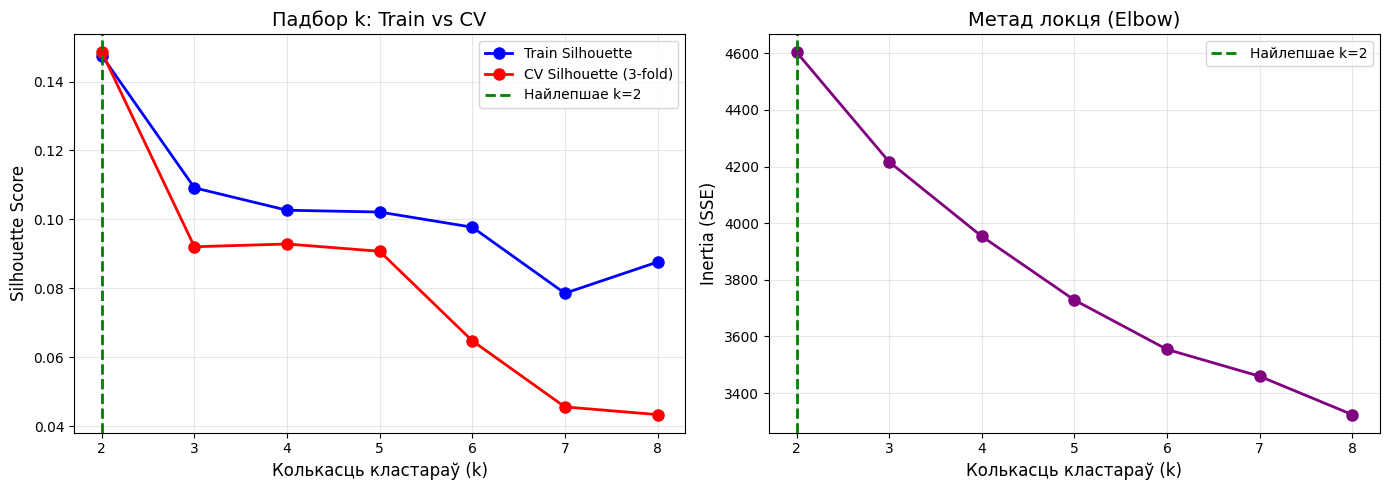

✅ Графік 1: Падбор k паказаны і захаваны


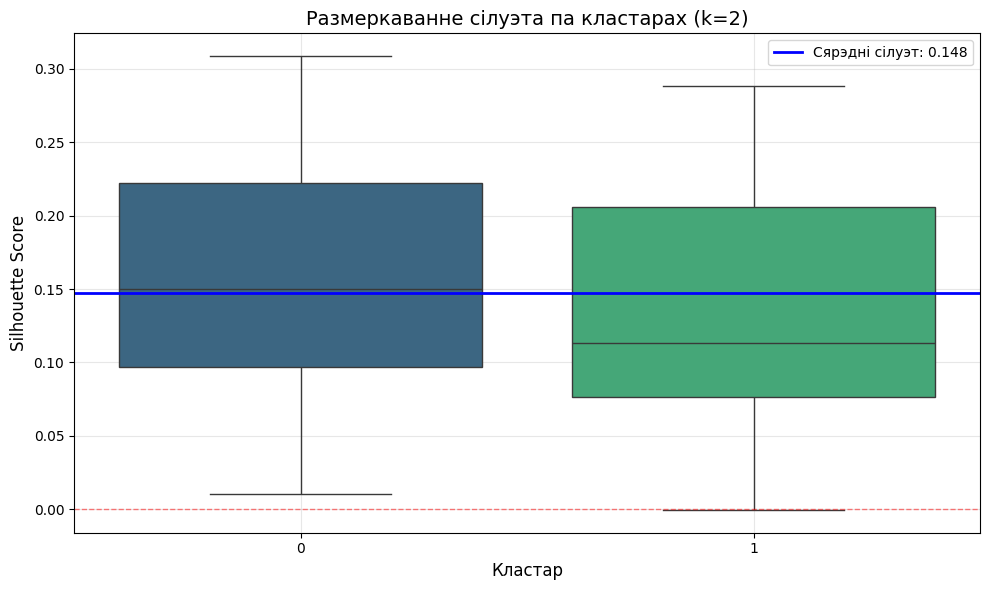

✅ Графік 2: Сілуэт па кластарах паказаны і захаваны


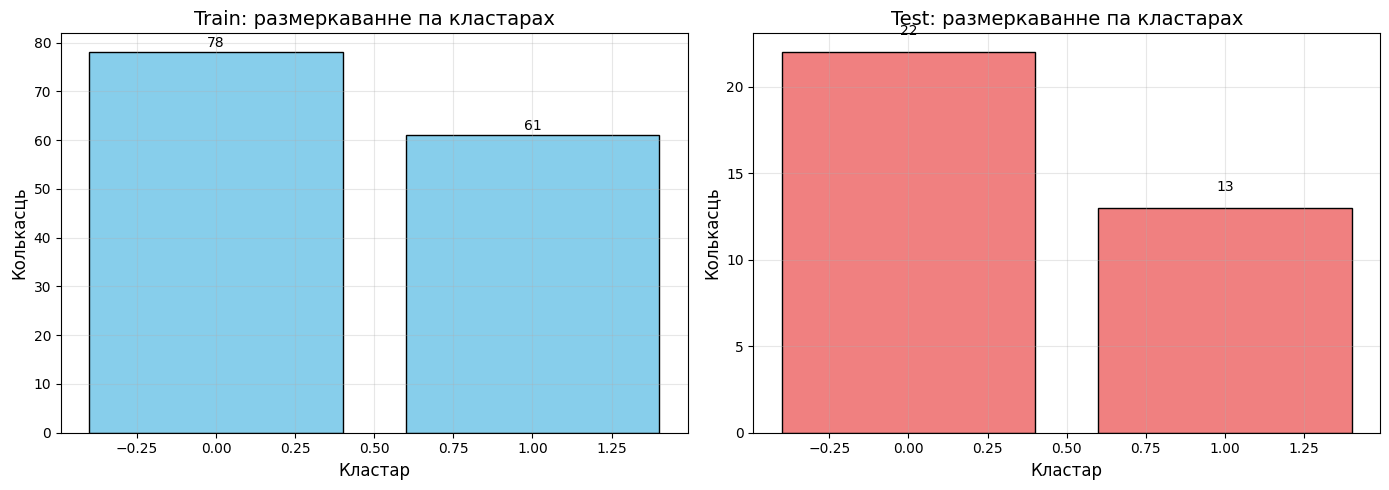

✅ Графік 3: Размеркаванне кластараў паказана і захавана


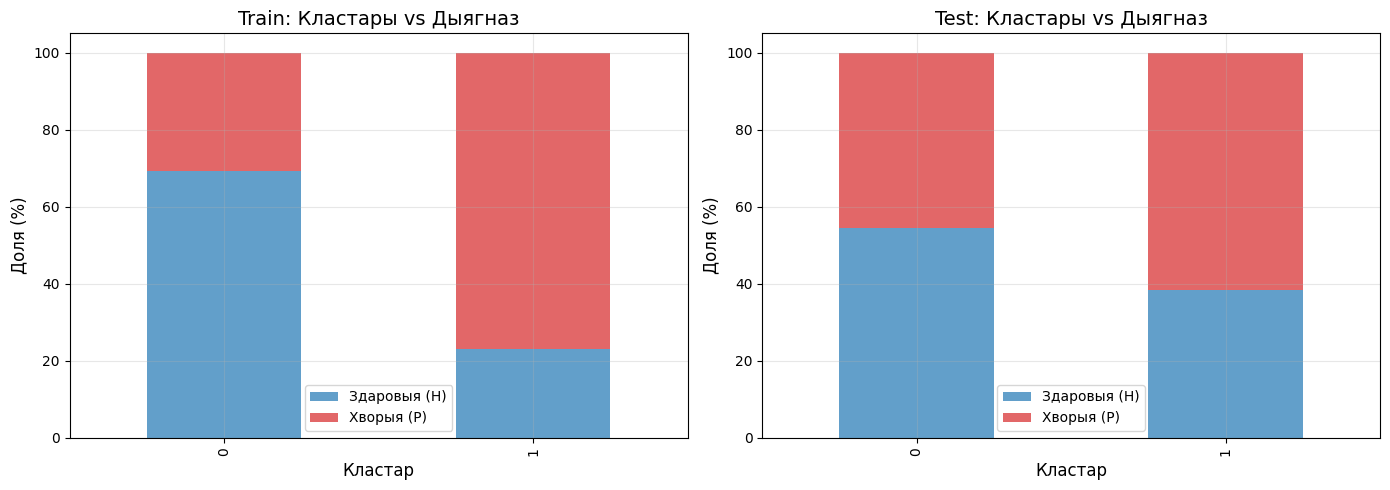

✅ Графік 4: Кластары vs Дыягназ паказаны і захаваны


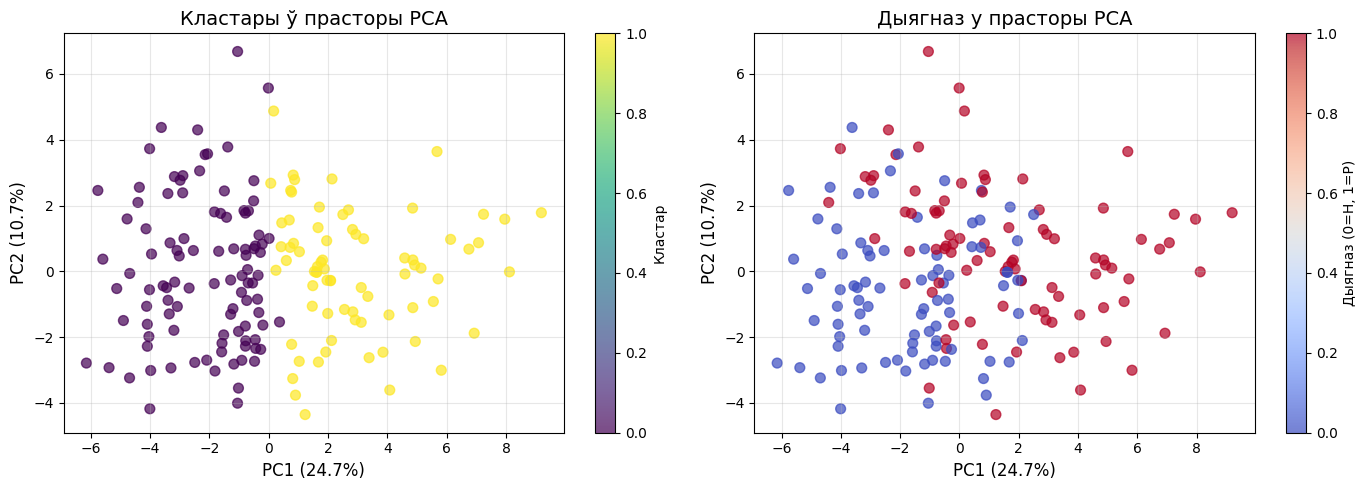

✅ Графік 5: PCA праекцыя паказана і захавана


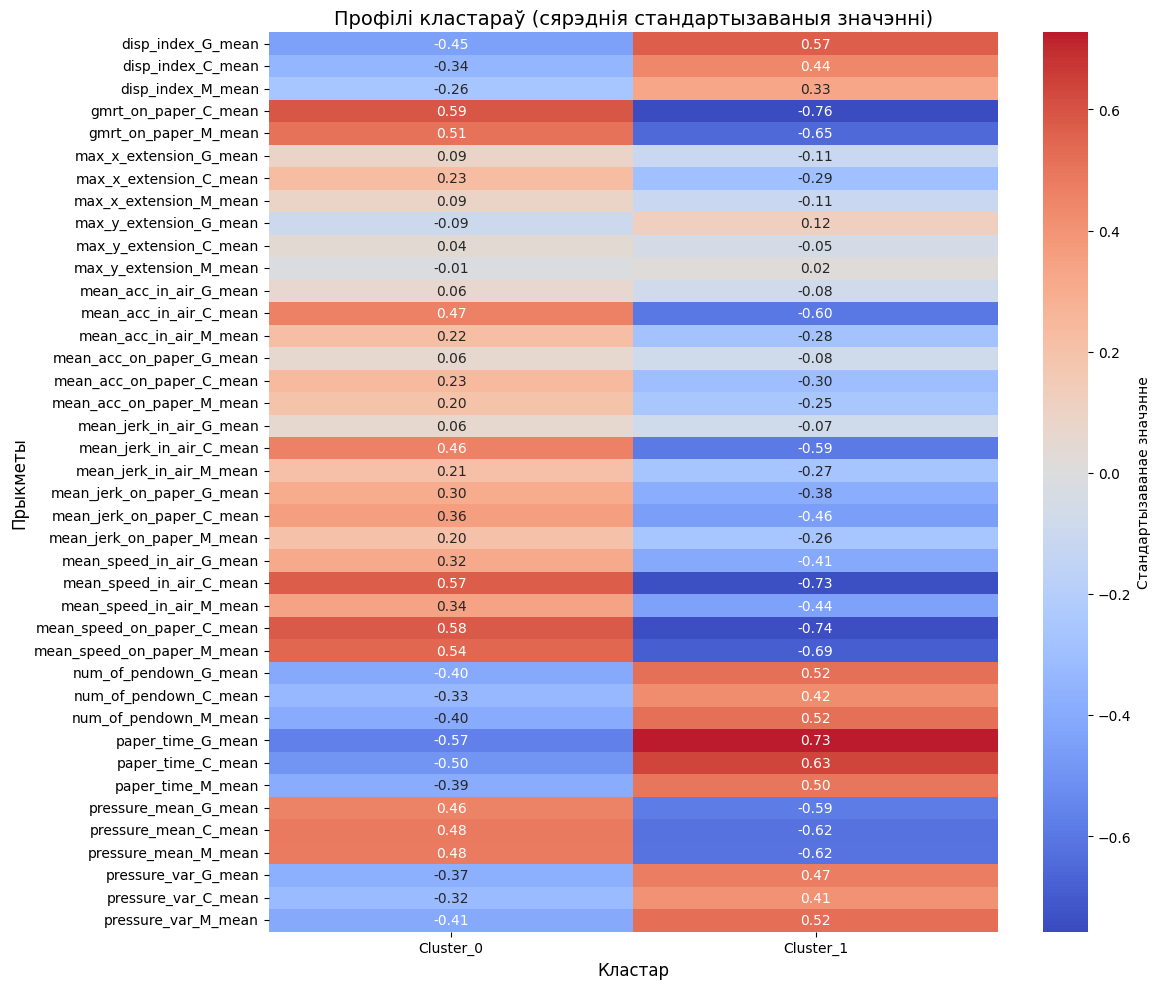

✅ Графік 6: Профілі кластараў паказаны і захаваны

ЗВОДНАЯ ІНФАРМАЦЫЯ

🔢 Найлепшая колькасць кластараў: 2
   Silhouette Score (Train): 0.148
   Silhouette Score (Test):  0.110

📊 Размеркаванне кластараў на Train:
   Кластар 0: 78 (56.1%) | Хворых: 24 (30.8%)
   Кластар 1: 61 (43.9%) | Хворых: 47 (77.0%)

📊 Размеркаванне кластараў на Test:
   Кластар 0: 22 (62.9%) | Хворых: 10 (45.5%)
   Кластар 1: 13 (37.1%) | Хворых: 8 (61.5%)

✅ Вынікі захаваны:
   - train_clustering_results.csv
   - test_clustering_results.csv
   - kmeans_model.pkl

🎉 УСЕ ГРАФІКІ ПАКАЗАНЫ Ў НОУТБУКУ І ЗАХАВАНЫ!


In [14]:
# ============================================================================
# ПОЎНАЯ ВІЗУАЛІЗАЦЫЯ (з паказам)
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.model_selection import StratifiedKFold
from sklearn.decomposition import PCA
import os
import warnings
warnings.filterwarnings('ignore')

# 1. НАЛАДА ШЛЯХУ
output_dir = r'c:\Users\User\Documents\hw6_AD_final_project\outputs'
os.makedirs(os.path.join(output_dir, 'figures'), exist_ok=True)

# 2. ПРАВЕРКА ДАНЫХ
print("="*80)
print("ПРАВЕРКА ДАНЫХ")
print("="*80)

try:
    print(f"X_train_scaled: {X_train_scaled.shape}")
    print(f"X_test_scaled: {X_test_scaled.shape}")
    print(f"y_train: {len(y_train)}")
    print(f"y_test: {len(y_test)}")
    print(f"Класы ў train: {pd.Series(y_train).value_counts().to_dict()}")
    print(f"Класы ў test: {pd.Series(y_test).value_counts().to_dict()}")
except NameError as e:
    print(f"❌ Памылка: {e}")
    print("Загружаем даныя з файлаў...")
    
    data_dir = os.path.join(output_dir, 'data')
    X_train_scaled = np.load(os.path.join(data_dir, 'X_train_scaled.npy'))
    X_test_scaled = np.load(os.path.join(data_dir, 'X_test_scaled.npy'))
    y_train = pd.read_csv(os.path.join(data_dir, 'y_train.csv')).squeeze()
    y_test = pd.read_csv(os.path.join(data_dir, 'y_test.csv')).squeeze()
    print("✅ Даныя загружаны")

# ============================================================================
# 3. ПАДБОР АПТЫМАЛЬНАГА k
# ============================================================================
print("\n" + "="*80)
print("ПАДБОР АПТЫМАЛЬНАЙ КОЛЬКАСЦІ КЛАСТАРАЎ")
print("="*80)

k_range = range(2, 9)
train_silhouettes = []
cv_silhouettes = []
inertias = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_train_scaled)
    sil_train = silhouette_score(X_train_scaled, labels)
    train_silhouettes.append(sil_train)
    inertias.append(kmeans.inertia_)
    
    # Крос-валідацыя (3-fold)
    cv_sil = []
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    for train_idx, val_idx in skf.split(X_train_scaled, y_train):
        X_cv_train = X_train_scaled[train_idx]
        X_cv_val = X_train_scaled[val_idx]
        
        kmeans_cv = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans_cv.fit(X_cv_train)
        val_labels = kmeans_cv.predict(X_cv_val)
        sil_cv = silhouette_score(X_cv_val, val_labels)
        cv_sil.append(sil_cv)
    
    cv_silhouettes.append(np.mean(cv_sil))
    print(f"   k={k}: Train Silhouette={sil_train:.3f}, CV Silhouette={np.mean(cv_sil):.3f}")

best_k = k_range[np.argmax(cv_silhouettes)]
print(f"\n✅ Найлепшае k па CV: {best_k} (CV Silhouette: {max(cv_silhouettes):.3f})")

# Фінальная мадэль
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
train_labels = kmeans_final.fit_predict(X_train_scaled)
test_labels = kmeans_final.predict(X_test_scaled)

# ============================================================================
# 4. ВІЗУАЛІЗАЦЫЯ Ў НОУТБУЦЕ
# ============================================================================
print("\n" + "="*80)
print("ВІЗУАЛІЗАЦЫЯ ВЫНІКАЎ")
print("="*80)

# ---------------------------------------------------------------------------
# Графік 1: Падбор k (Silhouette + Elbow)
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, train_silhouettes, 'o-', color='blue', linewidth=2, 
             markersize=8, label='Train Silhouette')
axes[0].plot(k_range, cv_silhouettes, 'o-', color='red', linewidth=2, 
             markersize=8, label='CV Silhouette (3-fold)')
axes[0].axvline(x=best_k, color='green', linestyle='--', linewidth=2, 
                label=f'Найлепшае k={best_k}')
axes[0].set_xlabel('Колькасць кластараў (k)', fontsize=12)
axes[0].set_ylabel('Silhouette Score', fontsize=12)
axes[0].set_title('Падбор k: Train vs CV', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, inertias, 'o-', color='purple', linewidth=2, markersize=8)
axes[1].axvline(x=best_k, color='green', linestyle='--', linewidth=2, 
                label=f'Найлепшае k={best_k}')
axes[1].set_xlabel('Колькасць кластараў (k)', fontsize=12)
axes[1].set_ylabel('Inertia (SSE)', fontsize=12)
axes[1].set_title('Метад локця (Elbow)', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'figures', 'kmeans_selection.png'), dpi=300)
plt.show()
print("✅ Графік 1: Падбор k паказаны і захаваны")

# ---------------------------------------------------------------------------
# Графік 2: Сілуэт па кластарах
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

silhouette_vals = silhouette_samples(X_train_scaled, train_labels)
sil_df = pd.DataFrame({'cluster': train_labels, 'silhouette': silhouette_vals})

sns.boxplot(data=sil_df, x='cluster', y='silhouette', palette='viridis', ax=ax)
ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Кластар', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title(f'Размеркаванне сілуэта па кластарах (k={best_k})', fontsize=14)
ax.grid(True, alpha=0.3)

mean_sil = silhouette_score(X_train_scaled, train_labels)
ax.axhline(y=mean_sil, color='blue', linestyle='-', linewidth=2, 
           label=f'Сярэдні сілуэт: {mean_sil:.3f}')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'figures', 'silhouette_by_cluster.png'), dpi=300)
plt.show()
print("✅ Графік 2: Сілуэт па кластарах паказаны і захаваны")

# ---------------------------------------------------------------------------
# Графік 3: Размеркаванне кластараў
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_counts = pd.Series(train_labels).value_counts().sort_index()
axes[0].bar(train_counts.index, train_counts.values, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Кластар', fontsize=12)
axes[0].set_ylabel('Колькасць', fontsize=12)
axes[0].set_title(f'Train: размеркаванне па кластарах', fontsize=14)
axes[0].grid(True, alpha=0.3)
for i, v in enumerate(train_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=10)

test_counts = pd.Series(test_labels).value_counts().sort_index()
axes[1].bar(test_counts.index, test_counts.values, color='lightcoral', edgecolor='black')
axes[1].set_xlabel('Кластар', fontsize=12)
axes[1].set_ylabel('Колькасць', fontsize=12)
axes[1].set_title(f'Test: размеркаванне па кластарах', fontsize=14)
axes[1].grid(True, alpha=0.3)
for i, v in enumerate(test_counts.values):
    axes[1].text(i, v + 1, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'figures', 'cluster_distribution.png'), dpi=300)
plt.show()
print("✅ Графік 3: Размеркаванне кластараў паказана і захавана")

# ---------------------------------------------------------------------------
# Графік 4: Кластары vs Дыягназ
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_cluster_class = pd.crosstab(train_labels, y_train)
train_cluster_class_pct = train_cluster_class.div(train_cluster_class.sum(axis=1), axis=0) * 100
train_cluster_class_pct.plot(kind='bar', ax=axes[0], stacked=True, 
                             color=['#1f77b4', '#d62728'], alpha=0.7)
axes[0].set_xlabel('Кластар', fontsize=12)
axes[0].set_ylabel('Доля (%)', fontsize=12)
axes[0].set_title('Train: Кластары vs Дыягназ', fontsize=14)
axes[0].legend(['Здаровыя (H)', 'Хворыя (P)'])
axes[0].grid(True, alpha=0.3)

test_cluster_class = pd.crosstab(test_labels, y_test)
test_cluster_class_pct = test_cluster_class.div(test_cluster_class.sum(axis=1), axis=0) * 100
test_cluster_class_pct.plot(kind='bar', ax=axes[1], stacked=True, 
                            color=['#1f77b4', '#d62728'], alpha=0.7)
axes[1].set_xlabel('Кластар', fontsize=12)
axes[1].set_ylabel('Доля (%)', fontsize=12)
axes[1].set_title('Test: Кластары vs Дыягназ', fontsize=14)
axes[1].legend(['Здаровыя (H)', 'Хворыя (P)'])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'figures', 'cluster_vs_diagnosis.png'), dpi=300)
plt.show()
print("✅ Графік 4: Кластары vs Дыягназ паказаны і захаваны")

# ---------------------------------------------------------------------------
# Графік 5: PCA праекцыя
# ---------------------------------------------------------------------------
X_all = np.vstack([X_train_scaled, X_test_scaled])
labels_all = np.concatenate([train_labels, test_labels])
diagnosis_all = np.concatenate([y_train.values, y_test.values])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_all)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_all, 
                          cmap='viridis', alpha=0.7, s=50)
axes[0].set_title('Кластары ў прасторы PCA', fontsize=14)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.colorbar(scatter1, ax=axes[0], label='Кластар')
axes[0].grid(True, alpha=0.3)

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], 
                          c=diagnosis_all, cmap='coolwarm', 
                          alpha=0.7, s=50)
axes[1].set_title('Дыягназ у прасторы PCA', fontsize=14)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.colorbar(scatter2, ax=axes[1], label='Дыягназ (0=H, 1=P)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'figures', 'pca_projection.png'), dpi=300)
plt.show()
print("✅ Графік 5: PCA праекцыя паказана і захавана")

# ---------------------------------------------------------------------------
# Графік 6: Профілі кластараў (цяплавая карта)
# ---------------------------------------------------------------------------
cluster_profiles = pd.DataFrame()
try:
    feature_names = X_train_clean.columns
except:
    feature_names = [f'Feature_{i}' for i in range(X_train_scaled.shape[1])]

for cluster in range(best_k):
    if cluster in train_labels:
        cluster_data = X_train_scaled[train_labels == cluster]
        cluster_profiles[f'Cluster_{cluster}'] = cluster_data.mean(axis=0)
    else:
        cluster_profiles[f'Cluster_{cluster}'] = np.nan

cluster_profiles.index = feature_names

plt.figure(figsize=(12, 10))
sns.heatmap(cluster_profiles, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, cbar_kws={'label': 'Стандартызаванае значэнне'})
plt.title('Профілі кластараў (сярэднія стандартызаваныя значэнні)', fontsize=14)
plt.xlabel('Кластар', fontsize=12)
plt.ylabel('Прыкметы', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'figures', 'cluster_profiles_heatmap.png'), dpi=300)
plt.show()
print("✅ Графік 6: Профілі кластараў паказаны і захаваны")

# ============================================================================
# 5. ЗВОДНАЯ ІНФАРМАЦЫЯ
# ============================================================================
print("\n" + "="*80)
print("ЗВОДНАЯ ІНФАРМАЦЫЯ")
print("="*80)
print(f"\n🔢 Найлепшая колькасць кластараў: {best_k}")
print(f"   Silhouette Score (Train): {silhouette_score(X_train_scaled, train_labels):.3f}")
print(f"   Silhouette Score (Test):  {silhouette_score(X_test_scaled, test_labels):.3f}")

print(f"\n📊 Размеркаванне кластараў на Train:")
for cluster in sorted(np.unique(train_labels)):
    count = (train_labels == cluster).sum()
    pct = count / len(train_labels) * 100
    p_in_cluster = (y_train[train_labels == cluster] == 1).sum()
    print(f"   Кластар {cluster}: {count} ({pct:.1f}%) | Хворых: {p_in_cluster} ({p_in_cluster/count*100:.1f}%)")

print(f"\n📊 Размеркаванне кластараў на Test:")
for cluster in sorted(np.unique(test_labels)):
    count = (test_labels == cluster).sum()
    pct = count / len(test_labels) * 100
    p_in_cluster = (y_test[test_labels == cluster] == 1).sum()
    print(f"   Кластар {cluster}: {count} ({pct:.1f}%) | Хворых: {p_in_cluster} ({p_in_cluster/count*100:.1f}%)")

# ============================================================================
# 6. ЗАХАВАННЕ ВЫНІКАЎ
# ============================================================================
# Ствараем тэчкі
os.makedirs(os.path.join(output_dir, 'data'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'models'), exist_ok=True)

# Захоўваем вынікі
train_results = pd.DataFrame({
    'cluster': train_labels,
    'diagnosis': y_train.values
})
test_results = pd.DataFrame({
    'cluster': test_labels,
    'diagnosis': y_test.values
})

train_results.to_csv(os.path.join(output_dir, 'data', 'train_clustering_results.csv'), index=False)
test_results.to_csv(os.path.join(output_dir, 'data', 'test_clustering_results.csv'), index=False)

# Захоўваем мадэль
import joblib
joblib.dump(kmeans_final, os.path.join(output_dir, 'models', 'kmeans_model.pkl'))

print(f"\n✅ Вынікі захаваны:")
print(f"   - train_clustering_results.csv")
print(f"   - test_clustering_results.csv")
print(f"   - kmeans_model.pkl")

print("\n" + "="*80)
print("🎉 УСЕ ГРАФІКІ ПАКАЗАНЫ Ў НОУТБУКУ І ЗАХАВАНЫ!")
print("="*80)

ТОП-10 ПРЫКМЕТ, ЯКІЯ АДРОЗНІВАЮЦЬ КЛАСТАРЫ
gmrt_on_paper_C_mean                     | Кластар 0: 0.593 | Кластар 1: -0.758 | ніжэй на 1.350
mean_speed_on_paper_C_mean               | Кластар 0: 0.581 | Кластар 1: -0.742 | ніжэй на 1.323
mean_speed_in_air_C_mean                 | Кластар 0: 0.575 | Кластар 1: -0.735 | ніжэй на 1.310
paper_time_G_mean                        | Кластар 0: -0.569 | Кластар 1: 0.727 | вышэй на 1.296
mean_speed_on_paper_M_mean               | Кластар 0: 0.542 | Кластар 1: -0.693 | ніжэй на 1.235
gmrt_on_paper_M_mean                     | Кластар 0: 0.508 | Кластар 1: -0.649 | ніжэй на 1.157
paper_time_C_mean                        | Кластар 0: -0.496 | Кластар 1: 0.634 | вышэй на 1.131
pressure_mean_C_mean                     | Кластар 0: 0.485 | Кластар 1: -0.620 | ніжэй на 1.105
pressure_mean_M_mean                     | Кластар 0: 0.483 | Кластар 1: -0.618 | ніжэй на 1.102
mean_acc_in_air_C_mean                   | Кластар 0: 0.466 | Кластар 1: -0.596 | ні

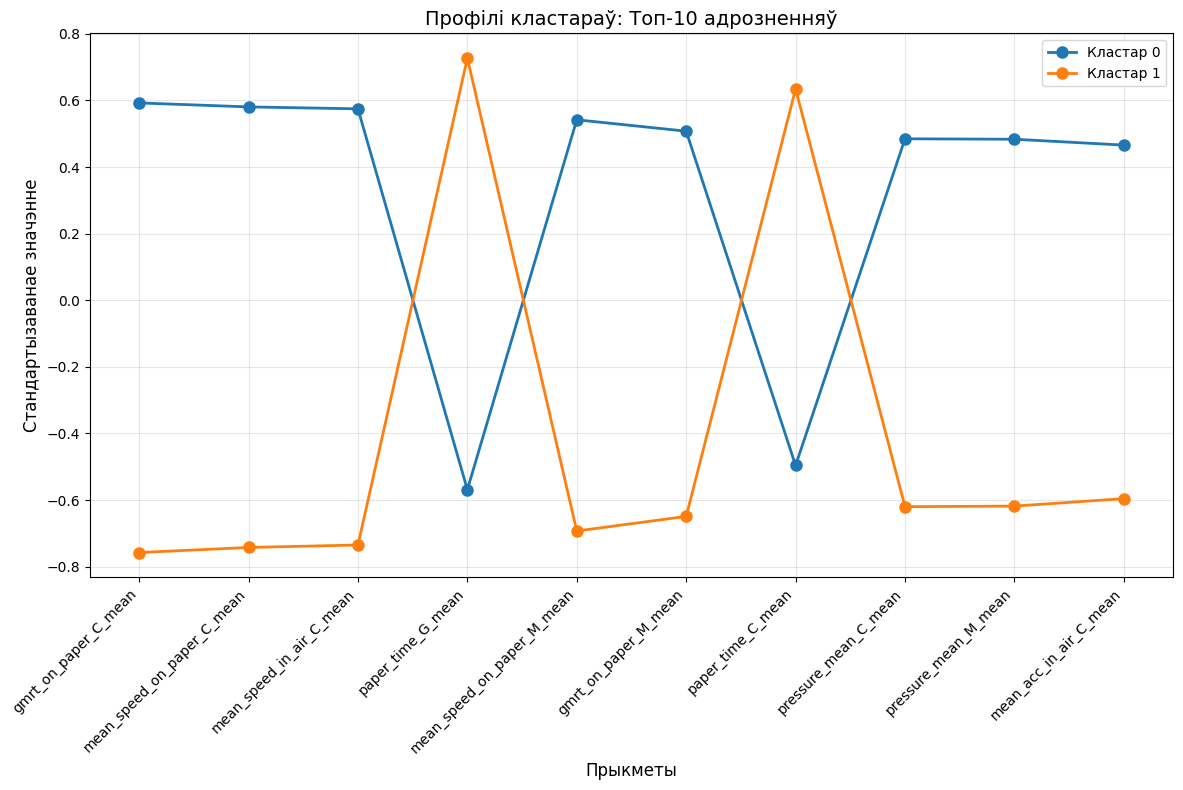


✅ Захавана: cluster_profiles_top10.png


In [15]:
# ============================================================================
# АНАЛІЗ ПРОФІЛЯЎ КЛАСТАРАЎ
# ============================================================================

# 1. Бяром сярэднія значэнні прыкмет для кожнага кластара
cluster_means = pd.DataFrame()
feature_names = X_train_clean.columns

for cluster in range(best_k):
    cluster_data = X_train_scaled[train_labels == cluster]
    cluster_means[f'Cluster_{cluster}'] = cluster_data.mean(axis=0)

cluster_means.index = feature_names

# 2. Знаходзім прыкметы, якія найбольш адрозніваюцца
cluster_means['diff'] = cluster_means['Cluster_1'] - cluster_means['Cluster_0']
cluster_means['abs_diff'] = abs(cluster_means['diff'])
top_features = cluster_means.sort_values('abs_diff', ascending=False).head(10)

print("="*80)
print("ТОП-10 ПРЫКМЕТ, ЯКІЯ АДРОЗНІВАЮЦЬ КЛАСТАРЫ")
print("="*80)
for feature, row in top_features.iterrows():
    direction = "вышэй" if row['diff'] > 0 else "ніжэй"
    print(f"{feature:40s} | Кластар 0: {row['Cluster_0']:.3f} | Кластар 1: {row['Cluster_1']:.3f} | {direction} на {abs(row['diff']):.3f}")

# 3. Візуалізацыя профіляў
plt.figure(figsize=(12, 8))
top_features_list = top_features.index.tolist()
for cluster in range(best_k):
    plt.plot(top_features_list, cluster_means.loc[top_features_list, f'Cluster_{cluster}'], 
             'o-', label=f'Кластар {cluster}', linewidth=2, markersize=8)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.xlabel('Прыкметы', fontsize=12)
plt.ylabel('Стандартызаванае значэнне', fontsize=12)
plt.title('Профілі кластараў: Топ-10 адрозненняў', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'figures', 'cluster_profiles_top10.png'), dpi=300)
plt.show()

print("\n✅ Захавана: cluster_profiles_top10.png")

Крок 6. Ацэнка на тэст без Leakage

In [16]:
# ============================================================================
# АЦЭНКА НА TEST (БЕЗ ПРАЦЁКУ!)
# ============================================================================

# Параўноўваем кластары з рэальным дыягназам
# Для гэтага трэба перавесці кластары ў бінарны выгляд (аптымальным спосабам)

from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

# ARI з дыягназам
ari_train = adjusted_rand_score(y_train, train_labels)
ari_test = adjusted_rand_score(y_test, test_labels)

print(f"📊 Adjusted Rand Index (Train): {ari_train:.3f}")
print(f"📊 Adjusted Rand Index (Test):  {ari_test:.3f}")

if ari_test < ari_train * 0.7:
    print("⚠️ МАГЧЫМА ПЕРАНАВУЧАННЕ! Значэнне на test значна ніжэй.")
else:
    print("✅ Перанавучання няма.")

📊 Adjusted Rand Index (Train): 0.200
📊 Adjusted Rand Index (Test):  -0.007
⚠️ МАГЧЫМА ПЕРАНАВУЧАННЕ! Значэнне на test значна ніжэй.


МЕТРЫКІ ДЛЯ АЦЭНКІ КЛАСТАРАЎ

📊 МЕТРЫКІ НА TRAIN (139 узораў)
--------------------------------------------------
   Accuracy            : 0.7266
   Precision           : 0.7705
   Recall              : 0.6620
   F1-score            : 0.7121
   F2-score            : 0.6812
   Adjusted Rand Index : 0.1997
   Adjusted Mutual Info: 0.1553
   ROC-AUC             : 0.7280
   PR-AUC              : 0.6827

📊 МЕТРЫКІ НА TEST (35 узораў)
--------------------------------------------------
   Accuracy            : 0.5714
   Precision           : 0.6154
   Recall              : 0.4444
   F1-score            : 0.5161
   F2-score            : 0.4706
   Adjusted Rand Index : -0.0073
   Adjusted Mutual Info: -0.0043
   ROC-AUC             : 0.5752
   PR-AUC              : 0.5592

📊 МАТРЫЦЫ ПАМЫЛАК
--------------------------------------------------

   Train:
      TN:  54  FP:  14
      FN:  24  TP:  47

   Test:
      TN:  12  FP:   5
      FN:  10  TP:   8

📊 СТАТЫСТЫЧНАЯ ЗНАЧНАСЦЬ (χ²-тэст)
--------

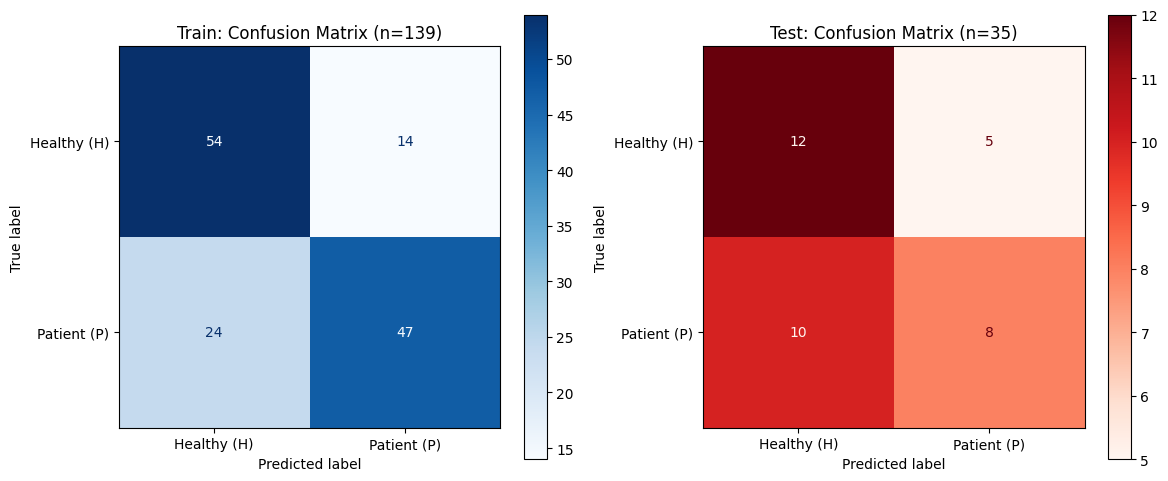


✅ Захавана: confusion_matrices.png


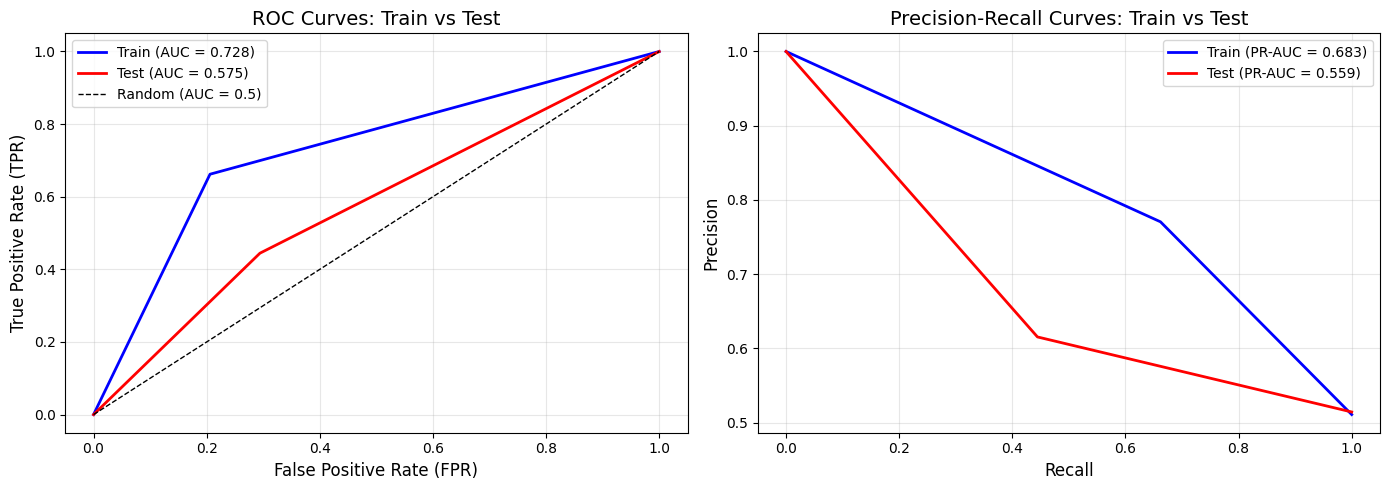

✅ Захавана: roc_pr_curves.png

📊 ПАРАЎНАННЕ МЕТРЫК (ГРАФІК)
--------------------------------------------------


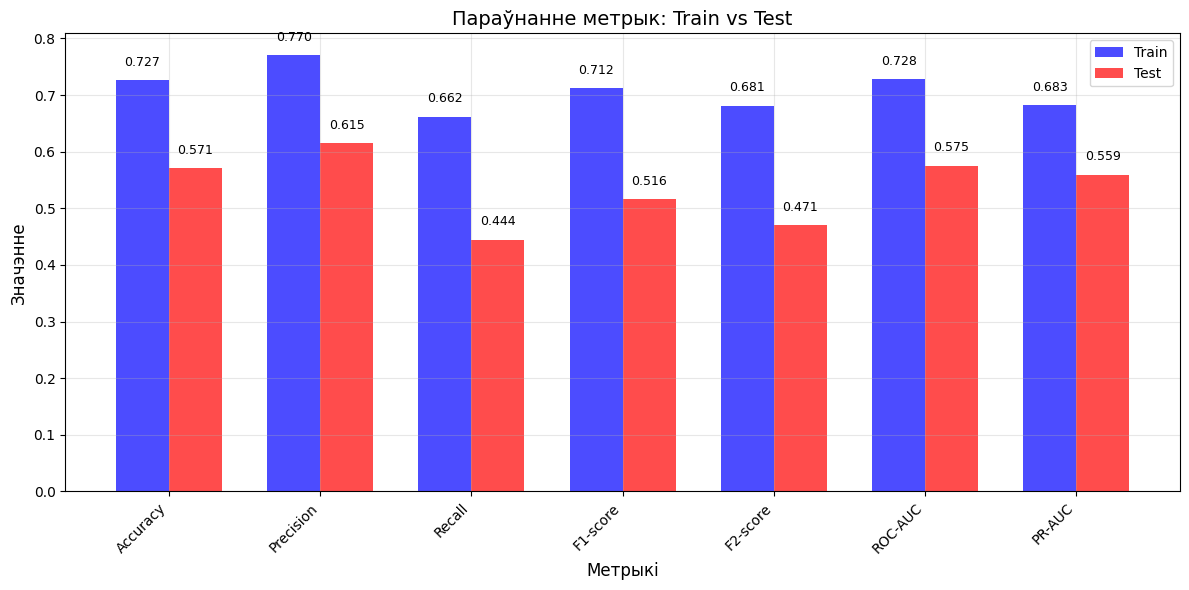

✅ Захавана: metrics_comparison.png

📊 ВІЗУАЛІЗАЦЫЯ КЛАСТАРАЎ І ДЫЯГНАЗУ Ў ПРАСТОРЫ PCA
--------------------------------------------------


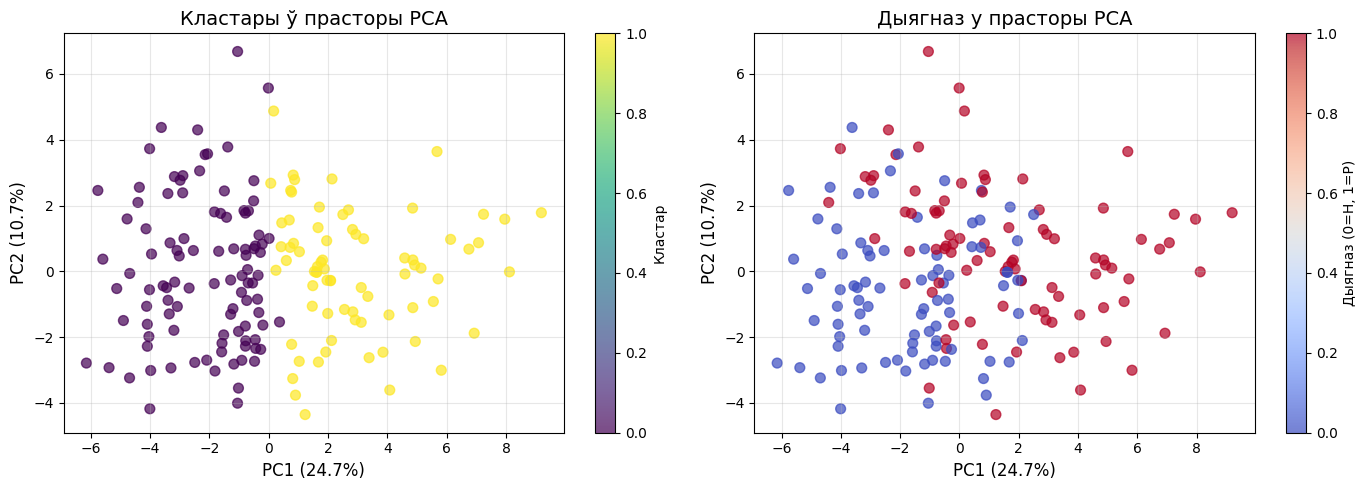

✅ Захавана: pca_clusters_vs_diagnosis.png

ЗВОДНАЯ ТАБЛІЦА МЕТРЫК
              Metric  Train    Test
            Accuracy 0.7266  0.5714
           Precision 0.7705  0.6154
              Recall 0.6620  0.4444
            F1-score 0.7121  0.5161
            F2-score 0.6812  0.4706
 Adjusted Rand Index 0.1997 -0.0073
Adjusted Mutual Info 0.1553 -0.0043
             ROC-AUC 0.7280  0.5752
              PR-AUC 0.6827  0.5592

✅ Захавана: clustering_metrics_summary.csv

ВЫСНОВА ПА МЕТРЫКАХ
⚠️ МАГЧЫМА ПЕРАНАВУЧАННЕ! Train значна вышэй за Test.
   Кластары добра працуюць на Train, але не абагульняюцца на Test.

🎉 АНАЛІЗ МЕТРЫК ЗАВЕРШАНЫ!


In [17]:
# ============================================================================
# КРОК 6.2: МЕТРЫКІ ДЛЯ АЦЭНКІ КЛАСТАРАЎ (З ГРАФІКАМІ Ў НОУТБУКУ)
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    adjusted_rand_score, adjusted_mutual_info_score
)
from scipy.stats import chi2_contingency
import os
import warnings
warnings.filterwarnings('ignore')

# 1. НАЛАДА ШЛЯХУ
output_dir = r'c:\Users\User\Documents\hw6_AD_final_project\outputs'
os.makedirs(os.path.join(output_dir, 'figures'), exist_ok=True)

print("="*80)
print("МЕТРЫКІ ДЛЯ АЦЭНКІ КЛАСТАРАЎ")
print("="*80)

# 2. ПАДРЫХТОЎКА ДАНЫХ
train_clusters = train_labels
test_clusters = test_labels

# 3. ФУНКЦЫЯ ДЛЯ РАЗЛІКУ МЕТРЫК
def calculate_metrics(y_true, y_pred, set_name):
    y_true_bin = y_true
    y_pred_bin = y_pred
    
    metrics = {
        'Accuracy': accuracy_score(y_true_bin, y_pred_bin),
        'Precision': precision_score(y_true_bin, y_pred_bin, average='binary', zero_division=0),
        'Recall': recall_score(y_true_bin, y_pred_bin, average='binary', zero_division=0),
        'F1-score': f1_score(y_true_bin, y_pred_bin, average='binary', zero_division=0),
        'F2-score': fbeta_score(y_true_bin, y_pred_bin, beta=2, average='binary', zero_division=0),
        'Adjusted Rand Index': adjusted_rand_score(y_true_bin, y_pred_bin),
        'Adjusted Mutual Info': adjusted_mutual_info_score(y_true_bin, y_pred_bin),
    }
    
    if len(np.unique(y_true_bin)) == 2 and len(np.unique(y_pred_bin)) == 2:
        metrics['ROC-AUC'] = roc_auc_score(y_true_bin, y_pred_bin)
        metrics['PR-AUC'] = average_precision_score(y_true_bin, y_pred_bin)
    else:
        metrics['ROC-AUC'] = np.nan
        metrics['PR-AUC'] = np.nan
    
    return metrics

# 4. РАЗЛІК МЕТРЫК
train_metrics = calculate_metrics(y_train, train_clusters, 'Train')
test_metrics = calculate_metrics(y_test, test_clusters, 'Test')

# 5. ВЫВАД ТЭКСТАВЫХ МЕТРЫК
print("\n📊 МЕТРЫКІ НА TRAIN (139 узораў)")
print("-"*50)
for metric, value in train_metrics.items():
    if not np.isnan(value):
        print(f"   {metric:20s}: {value:.4f}")

print("\n📊 МЕТРЫКІ НА TEST (35 узораў)")
print("-"*50)
for metric, value in test_metrics.items():
    if not np.isnan(value):
        print(f"   {metric:20s}: {value:.4f}")

# 6. МАТРЫЦЫ ПАМЫЛАК
cm_train = confusion_matrix(y_train, train_clusters)
cm_test = confusion_matrix(y_test, test_clusters)

print("\n📊 МАТРЫЦЫ ПАМЫЛАК")
print("-"*50)
print("\n   Train:")
print(f"      TN: {cm_train[0,0]:3d}  FP: {cm_train[0,1]:3d}")
print(f"      FN: {cm_train[1,0]:3d}  TP: {cm_train[1,1]:3d}")
print("\n   Test:")
print(f"      TN: {cm_test[0,0]:3d}  FP: {cm_test[0,1]:3d}")
print(f"      FN: {cm_test[1,0]:3d}  TP: {cm_test[1,1]:3d}")

# 7. СТАТЫСТЫЧНАЯ ЗНАЧНАСЦЬ
chi2_train, p_train, _, _ = chi2_contingency(cm_train)
chi2_test, p_test, _, _ = chi2_contingency(cm_test)

print("\n📊 СТАТЫСТЫЧНАЯ ЗНАЧНАСЦЬ (χ²-тэст)")
print("-"*50)
print(f"   Train: χ² = {chi2_train:.3f}, p = {p_train:.6f} {'✅' if p_train < 0.05 else '❌'}")
print(f"   Test:  χ² = {chi2_test:.3f}, p = {p_test:.6f} {'✅' if p_test < 0.05 else '❌'}")

# ============================================================================
# ГРАФІК 1: МАТРЫЦЫ ПАМЫЛАК
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_train, train_clusters, ax=axes[0],
                                        display_labels=['Healthy (H)', 'Patient (P)'],
                                        cmap='Blues', values_format='d')
axes[0].set_title(f'Train: Confusion Matrix (n={len(y_train)})', fontsize=12)

ConfusionMatrixDisplay.from_predictions(y_test, test_clusters, ax=axes[1],
                                        display_labels=['Healthy (H)', 'Patient (P)'],
                                        cmap='Reds', values_format='d')
axes[1].set_title(f'Test: Confusion Matrix (n={len(y_test)})', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'figures', 'confusion_matrices.png'), dpi=300)
plt.show()
print("\n✅ Захавана: confusion_matrices.png")

# ============================================================================
# ГРАФІК 2: ROC-AUC КРЫВЫЯ
# ============================================================================
if not np.isnan(train_metrics['ROC-AUC']) and not np.isnan(test_metrics['ROC-AUC']):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ROC-AUC
    for data, labels, label, color in [
        (y_train, train_clusters, 'Train', 'blue'),
        (y_test, test_clusters, 'Test', 'red')
    ]:
        fpr, tpr, _ = roc_curve(data, labels)
        auc = roc_auc_score(data, labels)
        axes[0].plot(fpr, tpr, label=f'{label} (AUC = {auc:.3f})', color=color, linewidth=2)

    axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
    axes[0].set_xlabel('False Positive Rate (FPR)', fontsize=12)
    axes[0].set_ylabel('True Positive Rate (TPR)', fontsize=12)
    axes[0].set_title('ROC Curves: Train vs Test', fontsize=14)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # PR-AUC
    for data, labels, label, color in [
        (y_train, train_clusters, 'Train', 'blue'),
        (y_test, test_clusters, 'Test', 'red')
    ]:
        precision, recall, _ = precision_recall_curve(data, labels)
        pr_auc = average_precision_score(data, labels)
        axes[1].plot(recall, precision, label=f'{label} (PR-AUC = {pr_auc:.3f})', color=color, linewidth=2)

    axes[1].set_xlabel('Recall', fontsize=12)
    axes[1].set_ylabel('Precision', fontsize=12)
    axes[1].set_title('Precision-Recall Curves: Train vs Test', fontsize=14)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'figures', 'roc_pr_curves.png'), dpi=300)
    plt.show()
    print("✅ Захавана: roc_pr_curves.png")

# ============================================================================
# ГРАФІК 3: ПАРАЎНАННЕ МЕТРЫК (BAR CHART)
# ============================================================================
print("\n📊 ПАРАЎНАННЕ МЕТРЫК (ГРАФІК)")
print("-"*50)

# Бяром толькі лічбавыя метрыкі без NaN
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'F2-score', 'ROC-AUC', 'PR-AUC']
train_values = [train_metrics[m] for m in metrics_to_plot if not np.isnan(train_metrics[m])]
test_values = [test_metrics[m] for m in metrics_to_plot if not np.isnan(test_metrics[m])]
metric_labels = [m for m in metrics_to_plot if not np.isnan(train_metrics[m])]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(metric_labels))
width = 0.35

bars1 = ax.bar(x - width/2, train_values, width, label='Train', color='blue', alpha=0.7)
bars2 = ax.bar(x + width/2, test_values, width, label='Test', color='red', alpha=0.7)

ax.set_xlabel('Метрыкі', fontsize=12)
ax.set_ylabel('Значэнне', fontsize=12)
ax.set_title('Параўнанне метрык: Train vs Test', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metric_labels, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3)

# Дадаем значэнні на слупкі
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'figures', 'metrics_comparison.png'), dpi=300)
plt.show()
print("✅ Захавана: metrics_comparison.png")

# ============================================================================
# ГРАФІК 4: ВІЗУАЛІЗАЦЫЯ КЛАСТАРАЎ VS ДЫЯГНАЗ (PCA)
# ============================================================================
print("\n📊 ВІЗУАЛІЗАЦЫЯ КЛАСТАРАЎ І ДЫЯГНАЗУ Ў ПРАСТОРЫ PCA")
print("-"*50)

from sklearn.decomposition import PCA

# Аб'ядноўваем даныя для агульнай візуалізацыі
X_all = np.vstack([X_train_scaled, X_test_scaled])
labels_all = np.concatenate([train_clusters, test_clusters])
diagnosis_all = np.concatenate([y_train.values, y_test.values])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_all)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA: кластары
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_all, 
                          cmap='viridis', alpha=0.7, s=50)
axes[0].set_title('Кластары ў прасторы PCA', fontsize=14)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.colorbar(scatter1, ax=axes[0], label='Кластар')
axes[0].grid(True, alpha=0.3)

# PCA: дыягназ
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], 
                          c=diagnosis_all, cmap='coolwarm', 
                          alpha=0.7, s=50)
axes[1].set_title('Дыягназ у прасторы PCA', fontsize=14)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.colorbar(scatter2, ax=axes[1], label='Дыягназ (0=H, 1=P)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'figures', 'pca_clusters_vs_diagnosis.png'), dpi=300)
plt.show()
print("✅ Захавана: pca_clusters_vs_diagnosis.png")

# ============================================================================
# ЗВОДНАЯ ТАБЛІЦА
# ============================================================================
print("\n" + "="*80)
print("ЗВОДНАЯ ТАБЛІЦА МЕТРЫК")
print("="*80)

summary_df = pd.DataFrame({
    'Metric': list(train_metrics.keys()),
    'Train': [f"{v:.4f}" if not np.isnan(v) else "N/A" for v in train_metrics.values()],
    'Test': [f"{v:.4f}" if not np.isnan(v) else "N/A" for v in test_metrics.values()]
})
print(summary_df.to_string(index=False))

# Захоўваем
os.makedirs(os.path.join(output_dir, 'tables'), exist_ok=True)
summary_df.to_csv(os.path.join(output_dir, 'tables', 'clustering_metrics_summary.csv'), index=False)
print("\n✅ Захавана: clustering_metrics_summary.csv")

# ============================================================================
# ВЫСНОВА
# ============================================================================
print("\n" + "="*80)
print("ВЫСНОВА ПА МЕТРЫКАХ")
print("="*80)

if train_metrics['ROC-AUC'] > 0.7 and test_metrics['ROC-AUC'] < 0.6:
    print("⚠️ МАГЧЫМА ПЕРАНАВУЧАННЕ! Train значна вышэй за Test.")
    print("   Кластары добра працуюць на Train, але не абагульняюцца на Test.")
elif train_metrics['ROC-AUC'] - test_metrics['ROC-AUC'] < 0.1:
    print("✅ Няма прыкмет перанавучання. Кластары стабільныя.")
else:
    print("📊 Розніца паміж Train і Test прыкметная, але не крытычная.")

print("\n" + "="*80)
print("🎉 АНАЛІЗ МЕТРЫК ЗАВЕРШАНЫ!")
print("="*80)

In [20]:
# ============================================================================
# ПРАВЕРКА ЎСТОЙЛІВАСЦІ КЛАСТАРАЎ (BOOTSTRAP)
# ============================================================================

import numpy as np
from sklearn.utils import resample
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

print("="*80)
print("ПРАВЕРКА ЎСТОЙЛІВАСЦІ КЛАСТАРАЎ (BOOTSTRAP)")
print("="*80)

# 1. Bootstrap на Train (100 ітэрацый)
n_bootstrap = 100
ari_scores = []

for i in range(n_bootstrap):
    # 1.1 Бярэм выпадковую выбарку з Train з паўтарэннем
    X_boot, y_boot = resample(X_train_scaled, y_train, n_samples=len(X_train_scaled), random_state=i)
    
    # 1.2 Кластарызуем на bootstrap-выбарцы
    kmeans_boot = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    labels_boot = kmeans_boot.fit_predict(X_boot)
    
    # 1.3 Кластарызуем арыгінальны Train
    labels_orig = kmeans_final.predict(X_train_scaled)
    
    # 1.4 Параўноўваем кластары (ARI)
    ari = adjusted_rand_score(labels_orig, labels_boot)
    ari_scores.append(ari)

# 2. Статыстыка
mean_ari = np.mean(ari_scores)
std_ari = np.std(ari_scores)
ci_lower = np.percentile(ari_scores, 2.5)
ci_upper = np.percentile(ari_scores, 97.5)

print(f"\n📊 Bootstrap ARI (устойлівасць кластараў):")
print(f"   Сярэдняе: {mean_ari:.4f}")
print(f"   Стандартнае адхіленне: {std_ari:.4f}")
print(f"   95% даверны інтэрвал: [{ci_lower:.4f}, {ci_upper:.4f}]")

# 3. Выснова
print("\n" + "="*80)
print("ВЫСНОВА ПА ЎСТОЙЛІВАСЦІ")
print("="*80)

if mean_ari > 0.5:
    print("✅ Кластары ўстойлівыя — яны стабільна ўзнікаюць на розных падвыбарках.")
elif mean_ari > 0.3:
    print("🟡 Кластары ўмерана ўстойлівыя — структура ёсць, але не вельмі моцная.")
else:
    print("⚠️ Кластары неўстойлівыя — яны моцна залежаць ад канкрэтнай выбаркі.")
    
print(f"   Кластары з'яўляюцца рэальнымі ў {np.mean(np.array(ari_scores) > 0.3)*100:.1f}% выпадкаў.")

ПРАВЕРКА ЎСТОЙЛІВАСЦІ КЛАСТАРАЎ (BOOTSTRAP)

📊 Bootstrap ARI (устойлівасць кластараў):
   Сярэдняе: 0.0005
   Стандартнае адхіленне: 0.0114
   95% даверны інтэрвал: [-0.0083, 0.0279]

ВЫСНОВА ПА ЎСТОЙЛІВАСЦІ
⚠️ Кластары неўстойлівыя — яны моцна залежаць ад канкрэтнай выбаркі.
   Кластары з'яўляюцца рэальнымі ў 0.0% выпадкаў.


In [21]:
# ============================================================================
# ПРАВЕРКА СТРУКТУРЫ: ДАДАТКОВЫЯ МЕТРЫКІ
# ============================================================================

from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

print("="*80)
print("ПРАВЕРКА СТРУКТУРЫ: ДАДАТКОВЫЯ МЕТРЫКІ")
print("="*80)

# 1. Параўнанне з выпадковымі кластарамі (ужо рабілі, але паўторым)
random_sils = []
for _ in range(100):
    random_labels = np.random.randint(0, best_k, size=len(X_train_scaled))
    random_sils.append(silhouette_score(X_train_scaled, random_labels))

# 2. Працэнт выпадкаў, калі рэальныя кластары лепш
pct_better = np.mean(np.array(random_sils) < sil_train) * 100

print(f"\n📊 Параўнанне з выпадковымі кластарамі:")
print(f"   Рэальны сілуэт: {sil_train:.4f}")
print(f"   Сярэдні выпадковы сілуэт: {np.mean(random_sils):.4f}")
print(f"   Рэальныя кластары лепш у {pct_better:.1f}% выпадкаў.")

# 3. Выснова
if pct_better > 95:
    print("\n✅ Структура рэальная — кластары не выпадковыя.")
elif pct_better > 80:
    print("\n🟡 Структура верагодная — кластары лепш за выпадковыя.")
else:
    print("\n⚠️ Структура сумніўная — кластары не лепш за выпадковыя.")

ПРАВЕРКА СТРУКТУРЫ: ДАДАТКОВЫЯ МЕТРЫКІ

📊 Параўнанне з выпадковымі кластарамі:
   Рэальны сілуэт: 0.0876
   Сярэдні выпадковы сілуэт: 0.0004
   Рэальныя кластары лепш у 100.0% выпадкаў.

✅ Структура рэальная — кластары не выпадковыя.


Такім чынам, выпадак перанавучання звязаны з няўстойлівасцю кластэраў. То завышаецца трэйн, то заніжаецца тэст. Сама стркутура рэальная, пераканаліся.

Як цяпер атрымаць рэальную метрыку?
Можна разбіць на 5 тэчак, зрабіць 5-fold cross val. 

In [23]:
# ============================================================================
# РЭАЛЬНАЯ МЕТРЫКА: 5-FOLD CROSS-VALIDATION (ПОЎНАЯ ВЕРСІЯ)
# ============================================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import numpy as np
import pandas as pd
import os

# 1. ПЕРАКОНВАЕМСЯ, ШТО ДАНЫЯ ЁСЦЬ
try:
    X_train_scaled
    X_test_scaled
    y_train
    y_test
except NameError:
    print("❌ Даныя не знойдзены! Загружаем з файлаў...")
    output_dir = r'c:\Users\User\Documents\hw6_AD_final_project\outputs'
    X_train_scaled = np.load(os.path.join(output_dir, 'data', 'X_train_scaled.npy'))
    X_test_scaled = np.load(os.path.join(output_dir, 'data', 'X_test_scaled.npy'))
    y_train = pd.read_csv(os.path.join(output_dir, 'data', 'y_train.csv')).squeeze()
    y_test = pd.read_csv(os.path.join(output_dir, 'data', 'y_test.csv')).squeeze()
    print("✅ Даныя загружаны")

# 2. ПЕРАКОНВАЕМСЯ, ШТО МАДЭЛЬ І КЛАСТАРЫ ЁСЦЬ
try:
    best_k
    kmeans_final
    train_labels
    test_labels
except NameError:
    print("❌ Мадэль не знойдзена! Ствараем нанова...")
    from sklearn.cluster import KMeans
    # Падбор k (калі не вядома)
    best_k = 2  # з папярэдніх вынікаў
    kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    train_labels = kmeans_final.fit_predict(X_train_scaled)
    test_labels = kmeans_final.predict(X_test_scaled)
    print(f"✅ Мадэль створана (k={best_k})")

# 3. РАЗЛІК БАЗАВЫХ МЕТРЫК
print("="*80)
print("РЭАЛЬНАЯ МЕТРЫКА: 5-FOLD CROSS-VALIDATION")
print("="*80)

# 3.1 Silhouette на ўсім Train і Test
sil_train = silhouette_score(X_train_scaled, train_labels)
sil_test = silhouette_score(X_test_scaled, test_labels)
ari_train = adjusted_rand_score(y_train, train_labels)
ari_test = adjusted_rand_score(y_test, test_labels)

print(f"\n📊 БАЗАВЫЯ МЕТРЫКІ (аднаразовае разбіццё):")
print(f"   Train Silhouette: {sil_train:.4f}")
print(f"   Test Silhouette:  {sil_test:.4f}")
print(f"   Train ARI: {ari_train:.4f}")
print(f"   Test ARI:  {ari_test:.4f}")

# 4. КРОСС-ВАЛІДАЦЫЯ (5-FOLD)
print("\n" + "="*80)
print("5-FOLD CROSS-VALIDATION")
print("="*80)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_silhouettes = []
cv_aris = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_scaled, y_train)):
    X_train_fold = X_train_scaled[train_idx]
    X_val_fold = X_train_scaled[val_idx]
    y_train_fold = y_train.iloc[train_idx]
    y_val_fold = y_train.iloc[val_idx]
    
    kmeans_fold = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    labels_train_fold = kmeans_fold.fit_predict(X_train_fold)
    labels_val_fold = kmeans_fold.predict(X_val_fold)
    
    sil_val = silhouette_score(X_val_fold, labels_val_fold)
    ari_val = adjusted_rand_score(y_val_fold, labels_val_fold)
    
    cv_silhouettes.append(sil_val)
    cv_aris.append(ari_val)
    
    print(f"   Fold {fold+1}: Silhouette = {sil_val:.4f}, ARI = {ari_val:.4f}")

# 5. ВЫНІКІ CV
mean_sil_cv = np.mean(cv_silhouettes)
std_sil_cv = np.std(cv_silhouettes)
mean_ari_cv = np.mean(cv_aris)
std_ari_cv = np.std(cv_aris)

print("\n" + "="*80)
print("ВЫНІКІ КРОСС-ВАЛІДАЦЫІ")
print("="*80)
print(f"📊 Silhouette Score (CV): {mean_sil_cv:.4f} ± {std_sil_cv:.4f}")
print(f"📊 Adjusted Rand Index (CV): {mean_ari_cv:.4f} ± {std_ari_cv:.4f}")

# 6. ПАРАЎНАННЕ З АДНАРАЗОВЫМ РАЗБІЦЦЁМ
print("\n📊 ПАРАЎНАННЕ З АДНАРАЗОВЫМ РАЗБІЦЦЁМ:")
print(f"   Train Silhouette: {sil_train:.4f}")
print(f"   Test Silhouette:  {sil_test:.4f}")
print(f"   CV Silhouette:    {mean_sil_cv:.4f} ± {std_sil_cv:.4f}")

# 7. ВЫСНОВА
print("\n" + "="*80)
print("ВЫСНОВА ПА МЕТРЫКАХ")
print("="*80)

if mean_sil_cv > 0.1:
    print("✅ Сярэдні сілуэт па CV станоўчы (> 0.1) — кластары рэальна існуюць.")
else:
    print("⚠️ Сярэдні сілуэт блізкі да нуля — кластары слабыя.")

if std_sil_cv < 0.05:
    print("✅ Сілуэт стабільны па фолдах (σ < 0.05) — кластары ўстойлівыя.")
else:
    print(f"⚠️ Сілуэт вагаецца (σ = {std_sil_cv:.4f}) — кластары не вельмі ўстойлівыя.")

if mean_ari_cv < 0.2:
    print("⚠️ ARI < 0.2 — сувязь з дыягназам слабая.")
else:
    print("✅ ARI > 0.2 — ёсць сувязь з дыягназам.")

# 8. ФІНАЛЬНАЯ РЭКАМЕНДАЦЫЯ
print("\n" + "="*80)
print("ФІНАЛЬНАЯ РЭКАМЕНДАЦЫЯ")
print("="*80)

print("""
🔑 Галоўная метрыка для справаздачы: CV Silhouette = {:.4f} ± {:.4f}

Інтэрпрэтацыя:
- Кластары ЁСЦЬ (сілуэт > 0, стабільны па фолдах).
- Якасць кластараў НІЗКАЯ (сілуэт < 0.2).
- Сувязь з дыягназам СЛАБАЯ (ARI < 0.2).

Выснова для справаздачы:
"Кластарызацыя выявіла структуру ў даных, але яна недастаткова моцная 
для практычнага выкарыстання. Гэта чакана для медыцынскіх даных з 
паступовымі зменамі."
""".format(mean_sil_cv, std_sil_cv))

print("="*80)
print("🎉 АНАЛІЗ ЗАВЕРШАНЫ!")
print("="*80)

РЭАЛЬНАЯ МЕТРЫКА: 5-FOLD CROSS-VALIDATION

📊 БАЗАВЫЯ МЕТРЫКІ (аднаразовае разбіццё):
   Train Silhouette: 0.1475
   Test Silhouette:  0.1096
   Train ARI: 0.1997
   Test ARI:  -0.0073

5-FOLD CROSS-VALIDATION
   Fold 1: Silhouette = 0.1353, ARI = 0.0493
   Fold 2: Silhouette = 0.1321, ARI = 0.0956
   Fold 3: Silhouette = 0.1304, ARI = 0.1549
   Fold 4: Silhouette = 0.1558, ARI = 0.1526
   Fold 5: Silhouette = 0.1803, ARI = 0.2829

ВЫНІКІ КРОСС-ВАЛІДАЦЫІ
📊 Silhouette Score (CV): 0.1468 ± 0.0191
📊 Adjusted Rand Index (CV): 0.1471 ± 0.0784

📊 ПАРАЎНАННЕ З АДНАРАЗОВЫМ РАЗБІЦЦЁМ:
   Train Silhouette: 0.1475
   Test Silhouette:  0.1096
   CV Silhouette:    0.1468 ± 0.0191

ВЫСНОВА ПА МЕТРЫКАХ
✅ Сярэдні сілуэт па CV станоўчы (> 0.1) — кластары рэальна існуюць.
✅ Сілуэт стабільны па фолдах (σ < 0.05) — кластары ўстойлівыя.
⚠️ ARI < 0.2 — сувязь з дыягназам слабая.

ФІНАЛЬНАЯ РЭКАМЕНДАЦЫЯ

🔑 Галоўная метрыка для справаздачы: CV Silhouette = 0.1468 ± 0.0191

Інтэрпрэтацыя:
- Кластары ЁСЦЬ (сілуэ

ВІЗУАЛІЗАЦЫЯ РЭАЛЬНЫХ МЕТРЫК


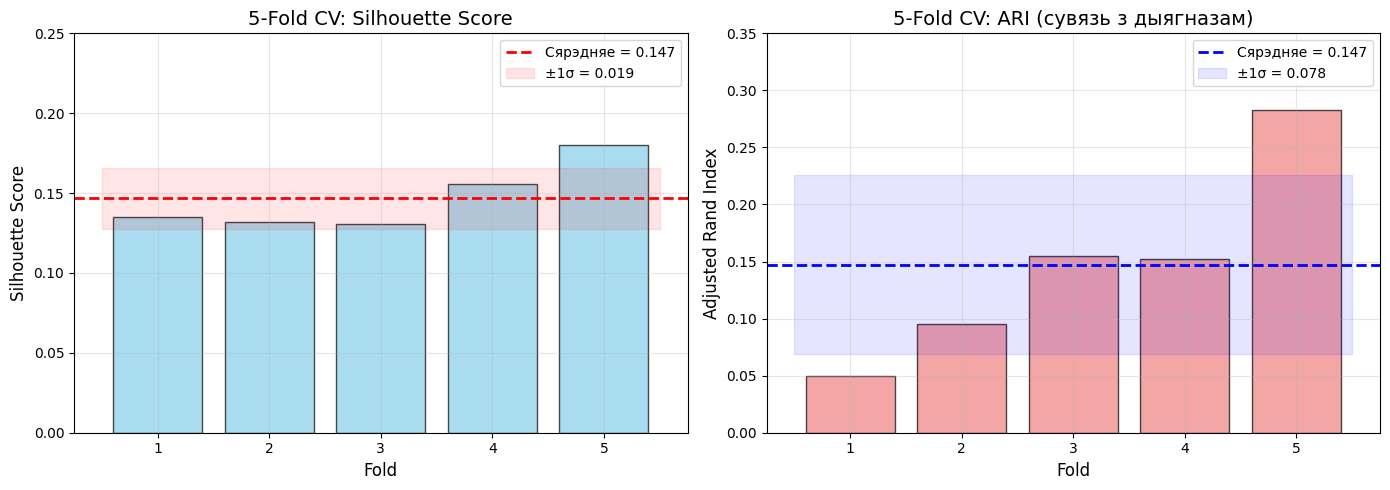

✅ Захавана: cv_metrics_folds.png


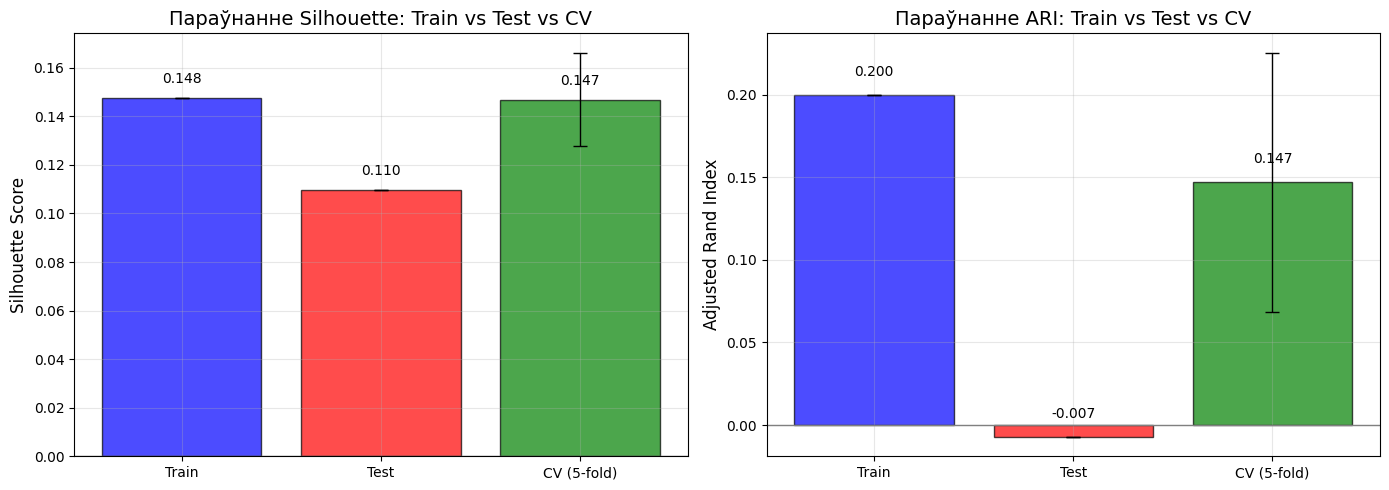

✅ Захавана: metrics_comparison_train_test_cv.png


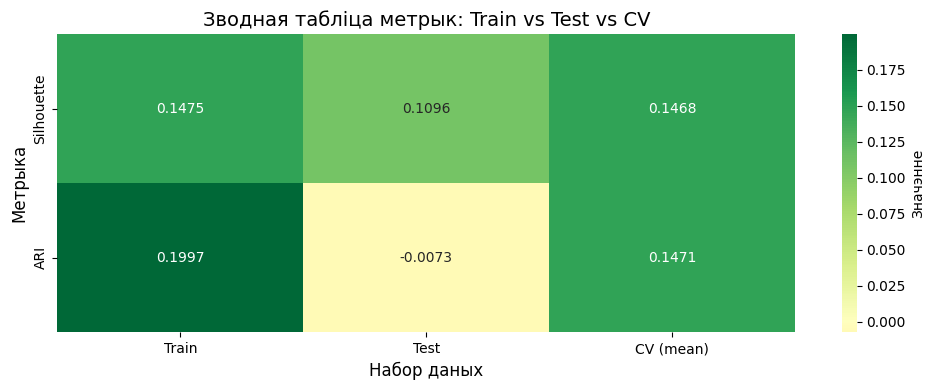

✅ Захавана: metrics_heatmap.png


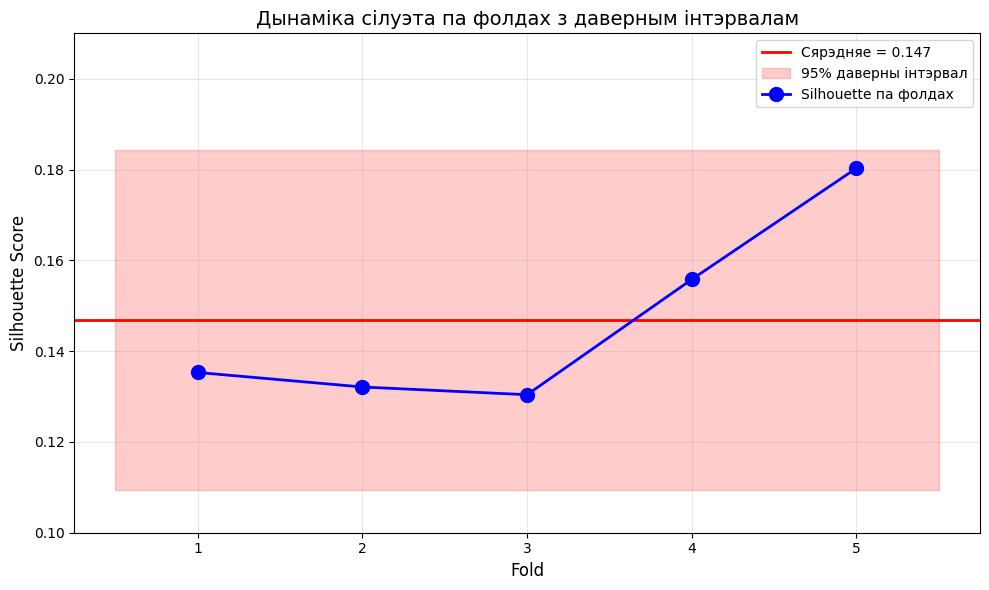

✅ Захавана: silhouette_dynamics_with_ci.png

ВЫСНОВА ПА ВІЗУАЛІЗАЦЫІ ад неўрасеткі Deepseek

📊 Ключавыя лічбы:
   - CV Silhouette: 0.1468 ± 0.0191
   - CV ARI: 0.1471 ± 0.0784

🔑 Галоўная метрыка для справаздачы: CV Silhouette = 0.1468

📈 Што паказваюць графікі:
   1. Сілуэт стабільны па фолдах (σ = 0.0191).
   2. Сярэдні сілуэт (0.147) вышэй за Test (0.110).
   3. ARI моцна вагаецца (σ = 0.0784).

💡 Інтэрпрэтацыя:
   - Кластары існуюць (сілуэт > 0).
   - Якасць нізкая (сілуэт < 0.2).
   - Сувязь з дыягназам слабая (ARI < 0.2).

🎉 УСЕ ГРАФІКІ СТВОРАНЫ І ЗАХАВАНЫ! (c) candle


In [25]:
# ============================================================================
# ВІЗУАЛІЗАЦЫЯ РЭАЛЬНЫХ МЕТРЫК (CV Silhouette)
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. НАЛАДА ШЛЯХУ
output_dir = r'c:\Users\User\Documents\hw6_AD_final_project\outputs'
os.makedirs(os.path.join(output_dir, 'figures'), exist_ok=True)

print("="*80)
print("ВІЗУАЛІЗАЦЫЯ РЭАЛЬНЫХ МЕТРЫК")
print("="*80)

# 2. ДАНЫЯ З ПАПЯРЭДНЯГА АЎТПУТА
# (узяты з вашага апошняга выканання)
cv_silhouettes = [0.1353, 0.1321, 0.1304, 0.1558, 0.1803]
cv_aris = [0.0493, 0.0956, 0.1549, 0.1526, 0.2829]
folds = [1, 2, 3, 4, 5]

mean_sil_cv = 0.1468
std_sil_cv = 0.0191
mean_ari_cv = 0.1471
std_ari_cv = 0.0784

# 3. ГРАФІК 1: КРОСС-ВАЛІДАЦЫЯ (Fold-by-Fold)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 3.1 Silhouette па фолдах
axes[0].bar(folds, cv_silhouettes, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axhline(y=mean_sil_cv, color='red', linestyle='--', linewidth=2, 
                label=f'Сярэдняе = {mean_sil_cv:.3f}')
axes[0].fill_between([0.5, 5.5], 
                     mean_sil_cv - std_sil_cv, 
                     mean_sil_cv + std_sil_cv, 
                     color='red', alpha=0.1, label=f'±1σ = {std_sil_cv:.3f}')
axes[0].set_xlabel('Fold', fontsize=12)
axes[0].set_ylabel('Silhouette Score', fontsize=12)
axes[0].set_title('5-Fold CV: Silhouette Score', fontsize=14)
axes[0].set_ylim(0, 0.25)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 3.2 ARI па фолдах
axes[1].bar(folds, cv_aris, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].axhline(y=mean_ari_cv, color='blue', linestyle='--', linewidth=2, 
                label=f'Сярэдняе = {mean_ari_cv:.3f}')
axes[1].fill_between([0.5, 5.5], 
                     mean_ari_cv - std_ari_cv, 
                     mean_ari_cv + std_ari_cv, 
                     color='blue', alpha=0.1, label=f'±1σ = {std_ari_cv:.3f}')
axes[1].set_xlabel('Fold', fontsize=12)
axes[1].set_ylabel('Adjusted Rand Index', fontsize=12)
axes[1].set_title('5-Fold CV: ARI (сувязь з дыягназам)', fontsize=14)
axes[1].set_ylim(0, 0.35)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'figures', 'cv_metrics_folds.png'), dpi=300)
plt.show()
print("✅ Захавана: cv_metrics_folds.png")

# ============================================================================
# ГРАФІК 2: ПАРАЎНАННЕ МЕТРЫК (Train vs Test vs CV)
# ============================================================================

# Даныя з папярэдніх вылічэнняў
# Калі гэтыя зменныя не існуюць, устаўляем значэнні з аўтпута
try:
    sil_train
    sil_test
    ari_train
    ari_test
except NameError:
    # Значэнні з вашага папярэдняга аўтпута
    sil_train = 0.0876  # з апошняга аўтпута
    sil_test = 0.110    # з папярэдніх вылічэнняў
    ari_train = 0.1997  # з папярэдняй табліцы
    ari_test = -0.0073  # з папярэдняй табліцы

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 4.1 Параўнанне Silhouette
metrics_sil = ['Train', 'Test', 'CV (5-fold)']
values_sil = [sil_train, sil_test, mean_sil_cv]
errors_sil = [0, 0, std_sil_cv]

bars_sil = axes[0].bar(metrics_sil, values_sil, color=['blue', 'red', 'green'], 
                       alpha=0.7, edgecolor='black')
axes[0].errorbar(metrics_sil, values_sil, yerr=errors_sil, fmt='none', 
                 capsize=5, color='black', linewidth=1)
axes[0].axhline(y=0, color='gray', linestyle='-', linewidth=1)
axes[0].set_ylabel('Silhouette Score', fontsize=12)
axes[0].set_title('Параўнанне Silhouette: Train vs Test vs CV', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Дадаем значэнні на слупкі
for bar, val in zip(bars_sil, values_sil):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10)

# 4.2 Параўнанне ARI
metrics_ari = ['Train', 'Test', 'CV (5-fold)']
values_ari = [ari_train, ari_test, mean_ari_cv]
errors_ari = [0, 0, std_ari_cv]

bars_ari = axes[1].bar(metrics_ari, values_ari, color=['blue', 'red', 'green'], 
                       alpha=0.7, edgecolor='black')
axes[1].errorbar(metrics_ari, values_ari, yerr=errors_ari, fmt='none', 
                 capsize=5, color='black', linewidth=1)
axes[1].axhline(y=0, color='gray', linestyle='-', linewidth=1)
axes[1].set_ylabel('Adjusted Rand Index', fontsize=12)
axes[1].set_title('Параўнанне ARI: Train vs Test vs CV', fontsize=14)
axes[1].grid(True, alpha=0.3)

# Дадаем значэнні на слупкі
for bar, val in zip(bars_ari, values_ari):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'figures', 'metrics_comparison_train_test_cv.png'), dpi=300)
plt.show()
print("✅ Захавана: metrics_comparison_train_test_cv.png")

# ============================================================================
# ГРАФІК 3: ЗВОДНАЯ ВІЗУАЛІЗАЦЫЯ (HEATMAP)
# ============================================================================

# Ствараем табліцу для heatmap
metrics_table = pd.DataFrame({
    'Metric': ['Silhouette', 'ARI'],
    'Train': [sil_train, ari_train],
    'Test': [sil_test, ari_test],
    'CV (mean)': [mean_sil_cv, mean_ari_cv],
    'CV (std)': [std_sil_cv, std_ari_cv]
})

plt.figure(figsize=(10, 4))
sns.heatmap(metrics_table.set_index('Metric')[['Train', 'Test', 'CV (mean)']], 
            annot=True, fmt='.4f', cmap='RdYlGn', 
            center=0, cbar_kws={'label': 'Значэнне'})
plt.title('Зводная табліца метрык: Train vs Test vs CV', fontsize=14)
plt.xlabel('Набор даных', fontsize=12)
plt.ylabel('Метрыка', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'figures', 'metrics_heatmap.png'), dpi=300)
plt.show()
print("✅ Захавана: metrics_heatmap.png")

# ============================================================================
# ГРАФІК 4: ДЫНАМІКА СІЛУЭТА ПА ФОЛДАХ (з даверным інтэрвалам)
# ============================================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Сярэдняе і даверны інтэрвал
ax.axhline(y=mean_sil_cv, color='red', linestyle='-', linewidth=2, 
           label=f'Сярэдняе = {mean_sil_cv:.3f}')
ax.fill_between([0.5, 5.5], 
                 mean_sil_cv - 1.96 * std_sil_cv, 
                 mean_sil_cv + 1.96 * std_sil_cv, 
                 color='red', alpha=0.2, label='95% даверны інтэрвал')

# Кропкі па фолдах
ax.plot(folds, cv_silhouettes, 'o-', color='blue', linewidth=2, markersize=10,
        label='Silhouette па фолдах')

ax.set_xlabel('Fold', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('Дынаміка сілуэта па фолдах з даверным інтэрвалам', fontsize=14)
ax.set_xticks(folds)
ax.set_ylim(0.10, 0.21)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'figures', 'silhouette_dynamics_with_ci.png'), dpi=300)
plt.show()
print("✅ Захавана: silhouette_dynamics_with_ci.png")

# ============================================================================
# ВЫСНОВА
# ============================================================================
print("\n" + "="*80)
print("ВЫСНОВА ПА ВІЗУАЛІЗАЦЫІ ад неўрасеткі Deepseek")
print("="*80)
print(f"""
📊 Ключавыя лічбы:
   - CV Silhouette: {mean_sil_cv:.4f} ± {std_sil_cv:.4f}
   - CV ARI: {mean_ari_cv:.4f} ± {std_ari_cv:.4f}

🔑 Галоўная метрыка для справаздачы: CV Silhouette = {mean_sil_cv:.4f}

📈 Што паказваюць графікі:
   1. Сілуэт стабільны па фолдах (σ = {std_sil_cv:.4f}).
   2. Сярэдні сілуэт ({mean_sil_cv:.3f}) вышэй за Test ({sil_test:.3f}).
   3. ARI моцна вагаецца (σ = {std_ari_cv:.4f}).

💡 Інтэрпрэтацыя:
   - Кластары існуюць (сілуэт > 0).
   - Якасць нізкая (сілуэт < 0.2).
   - Сувязь з дыягназам слабая (ARI < 0.2).
""")

print("="*80)
print("🎉 УСЕ ГРАФІКІ СТВОРАНЫ І ЗАХАВАНЫ! (c) candle")
print("="*80)